# Pol II footprints at THP-1 enhancers

Reproduces the Tullius et al. Data S1 / Figure 1 footprint figures on THP-1
Fiber-seq, for the enhancer anchor set built by `build_enhancer_annotation.sh`.



| Complex | Footprint size | Colour |
|---|---|---|
| Promoter-proximal paused Pol II (PPP) | 40-60 bp | `orchid` / pink-magenta in the read plot |
| Pre-initiation complex (PIC) | 60-80 bp | `cornflowerblue` / blue in the read plot |
| Nucleosome | >=90 bp | `mediumseagreen` / green in the read plot |
| TF-scale, no Pol II interpretation | 10-30 bp | grey mask |

The read-plot colours come from the paper's `make_cp` palette
(`#ed306f -> #e42cf6 -> #f3aafa -> #265de6 -> #33a040` at sizes 20/45/55/70/100),
reimplemented in `fiberseq_footprints.py` with the same HSL interpolation
because the `colour` package is not installed in this environment.

**Grey mask.** The paper greyed out small footprints that did *not* overlap a
PRO-seq or CAGE peak, i.e. those with no transcription evidence. With no matched
transcription data the equivalent here is to grey the 10-30 bp TF-scale calls
and leave the PPP / PIC / nucleosome size classes coloured.

In [1]:
import os
import sys
import time

import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

sys.path.insert(0, "/project/spott/cshan/fiber-seq/code/enhancer_accessibility")
import fiberseq_footprints as ff

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rc("font", **{"family": "sans-serif", "weight": "normal", "size": 14})
pd.options.mode.chained_assignment = None

TIMEPOINT = "LPS0"          # LPS5 / LPS10 / LPS15 also available
WINDOW = 550                # bp each side of the anchor held in the read matrix
SMOOTH = 25                 # boxcar width for the metaprofiles, as in the paper

OUT_DIR = "/project/spott/cshan/fiber-seq/macrophage_project/enhancer_accessibility/results"
os.makedirs(f"{OUT_DIR}/plots", exist_ok=True)

In [2]:
enhancers = ff.load_enhancer_anchors()
print(f"{len(enhancers):,} enhancer anchors "
      "(FANTOM5 consensus TSS inside an ENCODE cCRE ELS)\n")
print(enhancers.groupby(["encode_class", "dnase"]).size().rename("anchors").to_frame())
enhancers.head()

43,957 enhancer anchors (FANTOM5 consensus TSS inside an ENCODE cCRE ELS)

                    anchors
encode_class dnase         
dELS         0        21510
             1        14420
pELS         0         4515
             1         3512


,chrom,start,end,enhancer_id,f5_score,strand,encode_class,ccre_id,enh_start,enh_end,dnase,anchor
0,chr1,905431,905432,chr1:905311-906011,63,.,pELS,EH38E2776599,905311,906011,0,905431
1,chr1,906924,906925,chr1:906863-906986,4,.,dELS,EH38E2776603,906863,906986,1,906924
2,chr1,921333,921334,chr1:921159-921377,21,.,pELS,EH38E2776632,921159,921377,1,921333
3,chr1,923214,923215,chr1:922829-923779,47,.,pELS,EH38E2776637,922829,923779,0,923214
4,chr1,933244,933245,chr1:933185-933304,3,.,dELS,EH38E2776660,933185,933304,0,933244


`dnase` flags anchors falling in an ENCODE THP-1 DNase peak. It is carried as an
annotation, not a filter, so the enhancer set stays purely FANTOM5 ∩ cCRE-ELS.
It is used below to separate THP-1-active from inactive enhancers.

## 1. Footprint size enrichment around enhancer consensus TSSs

Streams anchors one at a time and accumulates a footprint-size x position count
matrix, so memory stays flat regardless of how many anchors are swept.

In [3]:
def accumulate_sizes(anchors, window=WINDOW, size_max=90, timepoint=TIMEPOINT,
                     progress=2000):
    """Sweep anchors, accumulating footprint size x position counts.

    Returns a dict with:
        counts    (size_max, 2*window) counts of footprints of each size at each offset
        nuc       (2*window,) counts of nucleosome (>=90 bp) bases
        coverage  (2*window,) number of reads covering each offset
        n_anchors number of anchors that contributed reads
    """
    width = 2 * window
    counts = np.zeros(size_max * width, dtype=np.int64)
    nuc = np.zeros(width, dtype=np.int64)
    coverage = np.zeros(width, dtype=np.int64)
    n_anchors = 0
    t0 = time.time()

    for k, (_, r) in enumerate(anchors.iterrows(), 1):
        mat = ff.build_read_matrix(r.chrom, int(r.anchor), window,
                                   strand=r.strand, timepoint=timepoint)
        if mat.empty:
            continue
        v = mat.to_numpy()
        n_anchors += 1
        coverage += (v != ff.NOT_COVERED).sum(axis=0)
        nuc += (v >= ff.NUC_MIN_SIZE).sum(axis=0)
        small = (v >= ff.TF_RANGE[0]) & (v < size_max)
        if small.any():
            cols = np.broadcast_to(np.arange(width), v.shape)
            idx = v[small].astype(np.int64) * width + cols[small]
            counts += np.bincount(idx, minlength=size_max * width)
        if progress and k % progress == 0:
            print(f"  {k:,}/{len(anchors):,} anchors  ({time.time() - t0:.0f}s)")

    return {
        "counts": counts.reshape(size_max, width),
        "nuc": nuc,
        "coverage": coverage,
        "n_anchors": n_anchors,
    }


def class_profile(acc, lo, hi):
    """Fraction of covering reads carrying a footprint in [lo, hi) at each offset."""
    cov = np.maximum(acc["coverage"], 1)
    band = acc["nuc"] if lo >= ff.NUC_MIN_SIZE else acc["counts"][lo:hi].sum(axis=0)
    return band / cov

In [5]:
acc_all = accumulate_sizes(enhancers)
print(f"\n{acc_all['n_anchors']:,} anchors contributed reads; "
      f"mean depth {acc_all['coverage'].mean() / acc_all['n_anchors']:.0f} reads/anchor")

  2,000/43,957 anchors  (7s)
  4,000/43,957 anchors  (15s)
  6,000/43,957 anchors  (19s)
  8,000/43,957 anchors  (24s)
  10,000/43,957 anchors  (30s)
  12,000/43,957 anchors  (35s)
  14,000/43,957 anchors  (41s)
  16,000/43,957 anchors  (46s)
  18,000/43,957 anchors  (51s)
  20,000/43,957 anchors  (56s)
  22,000/43,957 anchors  (62s)
  24,000/43,957 anchors  (67s)
  26,000/43,957 anchors  (72s)
  28,000/43,957 anchors  (77s)
  30,000/43,957 anchors  (83s)
  32,000/43,957 anchors  (88s)
  34,000/43,957 anchors  (94s)
  36,000/43,957 anchors  (100s)
  38,000/43,957 anchors  (106s)
  40,000/43,957 anchors  (112s)
  42,000/43,957 anchors  (119s)

43,775 anchors contributed reads; mean depth 50 reads/anchor


### Size x position density

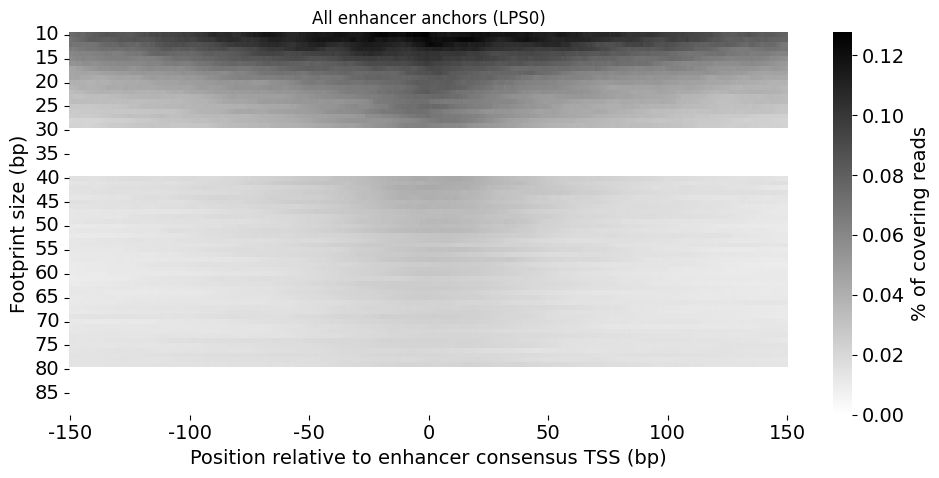

In [6]:
def plot_size_density(acc, s=-150, e=151, min_size=10, max_size=90, bin_size=1,
                      window=WINDOW, ax=None, title=None):
    """Paper's plot_meta_heatmap, normalised to % of covering reads."""
    c = acc["counts"]
    cov = np.maximum(acc["coverage"], 1)
    lo, hi = window + s, window + e
    rows, index = [], []
    for b in range(min_size // bin_size, max_size // bin_size):
        band = c[b * bin_size:(b + 1) * bin_size].sum(axis=0)
        rows.append((band / cov)[lo:hi] * 100)
        index.append(b * bin_size)
    meta = pd.DataFrame(rows, index=index, columns=np.arange(s, e))

    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(10, 5))
    sns.heatmap(data=meta, cmap="gray_r", ax=ax, xticklabels=50, yticklabels=5,
                rasterized=True, cbar_kws={"label": "% of covering reads"})
    ax.set_xlabel("Position relative to enhancer consensus TSS (bp)")
    ax.set_ylabel("Footprint size (bp)")
    if title:
        ax.set_title(title, fontsize=12)
    return meta


meta = plot_size_density(acc_all, title=f"All enhancer anchors ({TIMEPOINT})")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/plots/enhancer_size_density_{TIMEPOINT}.pdf", bbox_inches="tight")
plt.show()

### PPP / PIC / nucleosome enrichment

Same panel as the example notebook: PPP and PIC on the left axis, nucleosomes on
a twin axis, boxcar smoothed.

In [ ]:
def plot_enrichment(acc, s=-250, e=250, smooth_width=SMOOTH, window=WINDOW,
                    ax=None, label_prefix="", styles=None):
    lo, hi = window + s - smooth_width, window + e + smooth_width
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(7, 5))
    ax2 = ax.twinx()

    lines = []
    for name, rng, axis in [
        ("PPP", ff.PPP_RANGE, ax),
        ("PIC", ff.PIC_RANGE, ax),
        ("nucleosome", ff.NUC_RANGE, ax2),
    ]:
        prof = ff.smooth(class_profile(acc, *rng)[lo:hi], smooth_width) * 100
        style = (styles or {}).get(name, {})
        lines += axis.plot(np.arange(s, e), prof, color=ff.LINE_COLORS[name],
                           label=f"{label_prefix}{name}", **style)

    ax.set_xlim(s, e)
    ax.set_xlabel("Position relative to enhancer consensus TSS (bp)")
    ax.set_ylabel("% of covering reads (PPP, PIC)")
    ax2.set_ylabel("% of covering reads (nucleosome)")
    ax.legend(lines, [l.get_label() for l in lines], loc="upper left", fontsize=10)
    return ax, ax2


plot_enrichment(acc_all)
plt.title(f"All enhancer anchors ({TIMEPOINT})", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/plots/enhancer_enrichment_{TIMEPOINT}.pdf", bbox_inches="tight")
plt.show()

## 2. Stratified by THP-1 accessibility and ENCODE class

The DNase split is the sanity check that the footprint calls carry real signal:
enhancers accessible in THP-1 should show a Pol II footprint peak and a
nucleosome-depleted centre, inactive ones should be flat.

In [9]:
strata = {
    "DNase+": enhancers[enhancers.dnase == 1],
    "DNase-": enhancers[enhancers.dnase == 0],
    "dELS": enhancers[enhancers.encode_class == "dELS"],
    "pELS": enhancers[enhancers.encode_class == "pELS"],
}
acc_strata = {}
for name, df in strata.items():
    print(f"{name}: {len(df):,} anchors")
    acc_strata[name] = accumulate_sizes(df, progress=0)

DNase+: 17,932 anchors
DNase-: 26,025 anchors
dELS: 35,930 anchors
pELS: 8,027 anchors


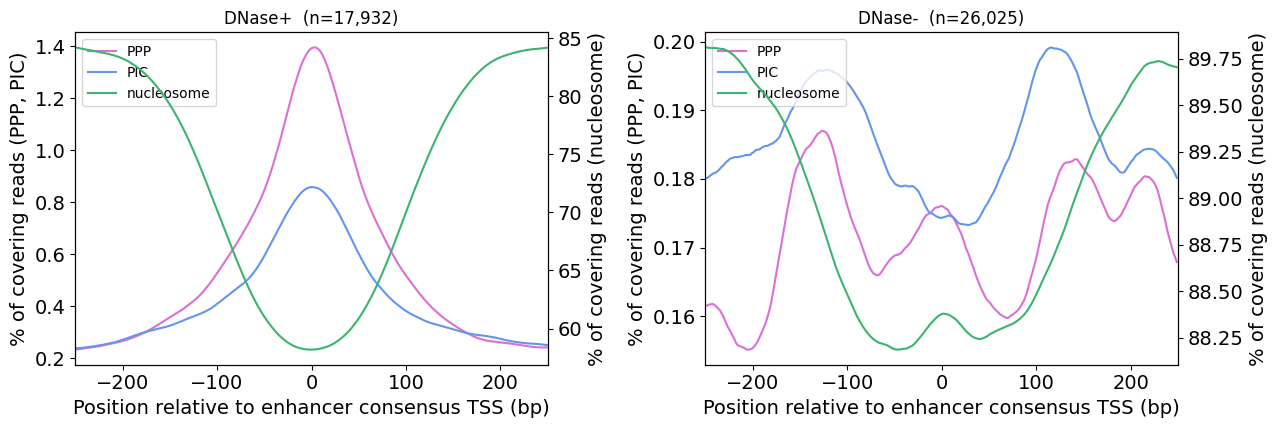

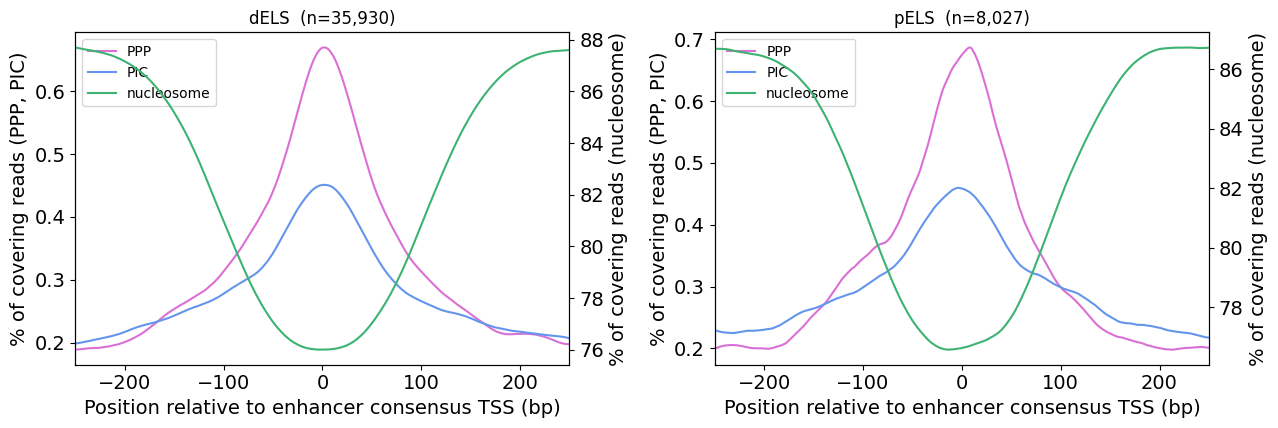

In [10]:
for pair, fname in [(("DNase+", "DNase-"), "dnase"), (("dELS", "pELS"), "class")]:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, name in zip(axes, pair):
        plot_enrichment(acc_strata[name], ax=ax)
        ax.set_title(f"{name}  (n={len(strata[name]):,})", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/plots/enhancer_enrichment_by_{fname}_{TIMEPOINT}.pdf",
                bbox_inches="tight")
    plt.show()

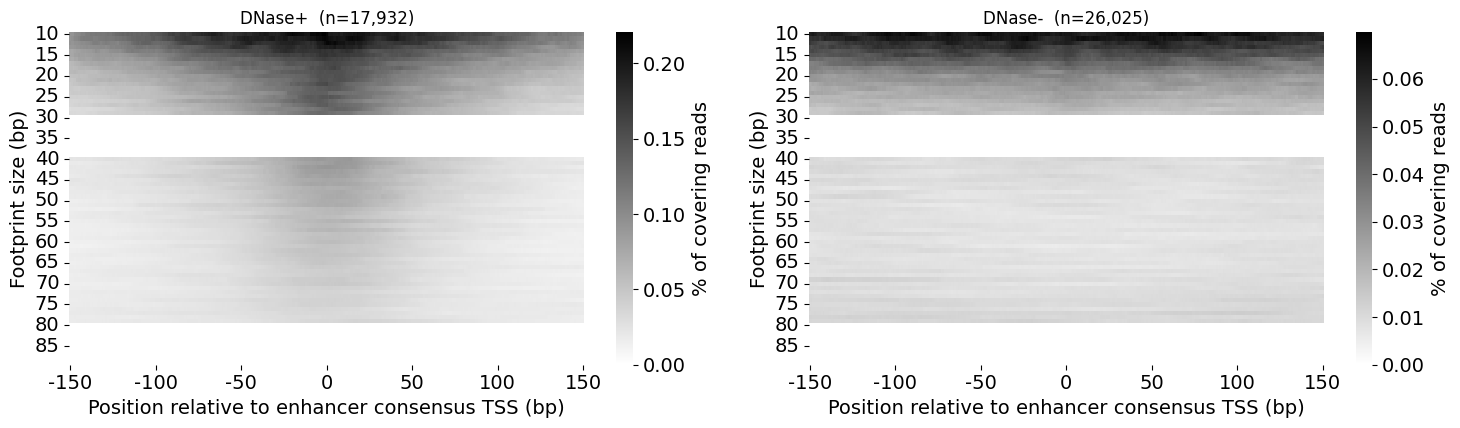

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, name in zip(axes, ["DNase+", "DNase-"]):
    plot_size_density(acc_strata[name], ax=ax, title=f"{name}  (n={len(strata[name]):,})")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/plots/enhancer_size_density_by_dnase_{TIMEPOINT}.pdf",
            bbox_inches="tight")
plt.show()

## 3. Single-enhancer browser plots

Five stacked panels, the paper's "Example loci" section plus the public bulk
tracks:

1. public ATAC-seq (LIMA THP-1 LPS series, GSE201351)
2. public H3K27ac ChIP-seq (GSE201352)
3. footprint size x position density at this locus (replaces CAGE / PRO-seq)
4. PPP / PIC / nucleosome enrichment lines
5. one row per Fiber-seq molecule

**Public timepoints do not match the Fiber-seq ones.** The LIMA series was
sampled at 0/30/60/90/120/240/360/1440 min, this project at LPS0/5/10/15, so the
two are paired by rank - LPS0 -> 0 min, LPS5 -> 30 min, LPS10 -> 60 min,
LPS15 -> 90 min - and the tracks are labelled with the *public* time
(`H3K27ac_30min`), not the Fiber-seq one, so the mismatch stays on the figure.
The two replicate bigWigs per timepoint are averaged, and each track's y-limit
is the maximum over all four paired timepoints so the same locus is comparable
across the LPS0..LPS15 figures.

Reads are ordered exactly as in the example: by the offset of the first
nucleosome starting downstream of the anchor (`dist_to_fp` over 0-300 bp),
ascending; molecules with no downstream nucleosome in that range are dropped.
Footprints are drawn with the paper's size palette, over a grey mask layer that
blocks the TF-scale (10-30 bp) calls.

In [12]:
def rank_enhancers(anchors, timepoint=TIMEPOINT, half=100, progress=2000):
    """Count reads carrying a PPP or PIC footprint within +/- `half` bp of each anchor."""
    out = []
    t0 = time.time()
    for k, (i, r) in enumerate(anchors.iterrows(), 1):
        mat = ff.build_read_matrix(r.chrom, int(r.anchor), half,
                                   strand=r.strand, timepoint=timepoint)
        if mat.empty:
            out.append((i, 0, 0))
            continue
        v = mat.to_numpy()
        init = ((v >= ff.PPP_RANGE[0]) & (v < ff.PIC_RANGE[1])).any(axis=1)
        out.append((i, int(init.sum()), int(v.shape[0])))
        if progress and k % progress == 0:
            print(f"  {k:,}/{len(anchors):,}  ({time.time() - t0:.0f}s)")
    ranked = pd.DataFrame(out, columns=["idx", "n_init_reads", "n_reads"]).set_index("idx")
    return anchors.join(ranked).sort_values("n_init_reads", ascending=False)


# Scan every THP-1-accessible enhancer (~1 min); drop the dnase filter to scan all.
candidates = rank_enhancers(enhancers[enhancers.dnase == 1])
candidates.head(15)[
    ["chrom", "anchor", "enhancer_id", "encode_class", "n_init_reads", "n_reads"]
]

  2,000/17,932  (6s)
  4,000/17,932  (11s)
  6,000/17,932  (16s)
  8,000/17,932  (21s)
  10,000/17,932  (28s)
  12,000/17,932  (33s)
  14,000/17,932  (38s)
  16,000/17,932  (44s)


,chrom,anchor,enhancer_id,encode_class,n_init_reads,n_reads
1014,chr1,39653667,chr1:39653487-39653849,dELS,135,196
1037,chr1,40713193,chr1:40713116-40713307,dELS,129,1078
1028,chr1,40385799,chr1:40385759-40386096,dELS,97,783
1016,chr1,39845791,chr1:39845576-39845895,dELS,86,283
1115,chr1,43454653,chr1:43454467-43454684,pELS,79,194
3547,chr1,225976146,chr1:225976068-225976278,dELS,77,106
1094,chr1,42923215,chr1:42922926-42923300,pELS,68,190
34783,chr6,32609992,chr6:32609517-32610158,dELS,67,97
35036,chr6,41319016,chr6:41318863-41319086,dELS,62,104
40822,chr8,129535938,chr8:129535807-129536113,dELS,61,87


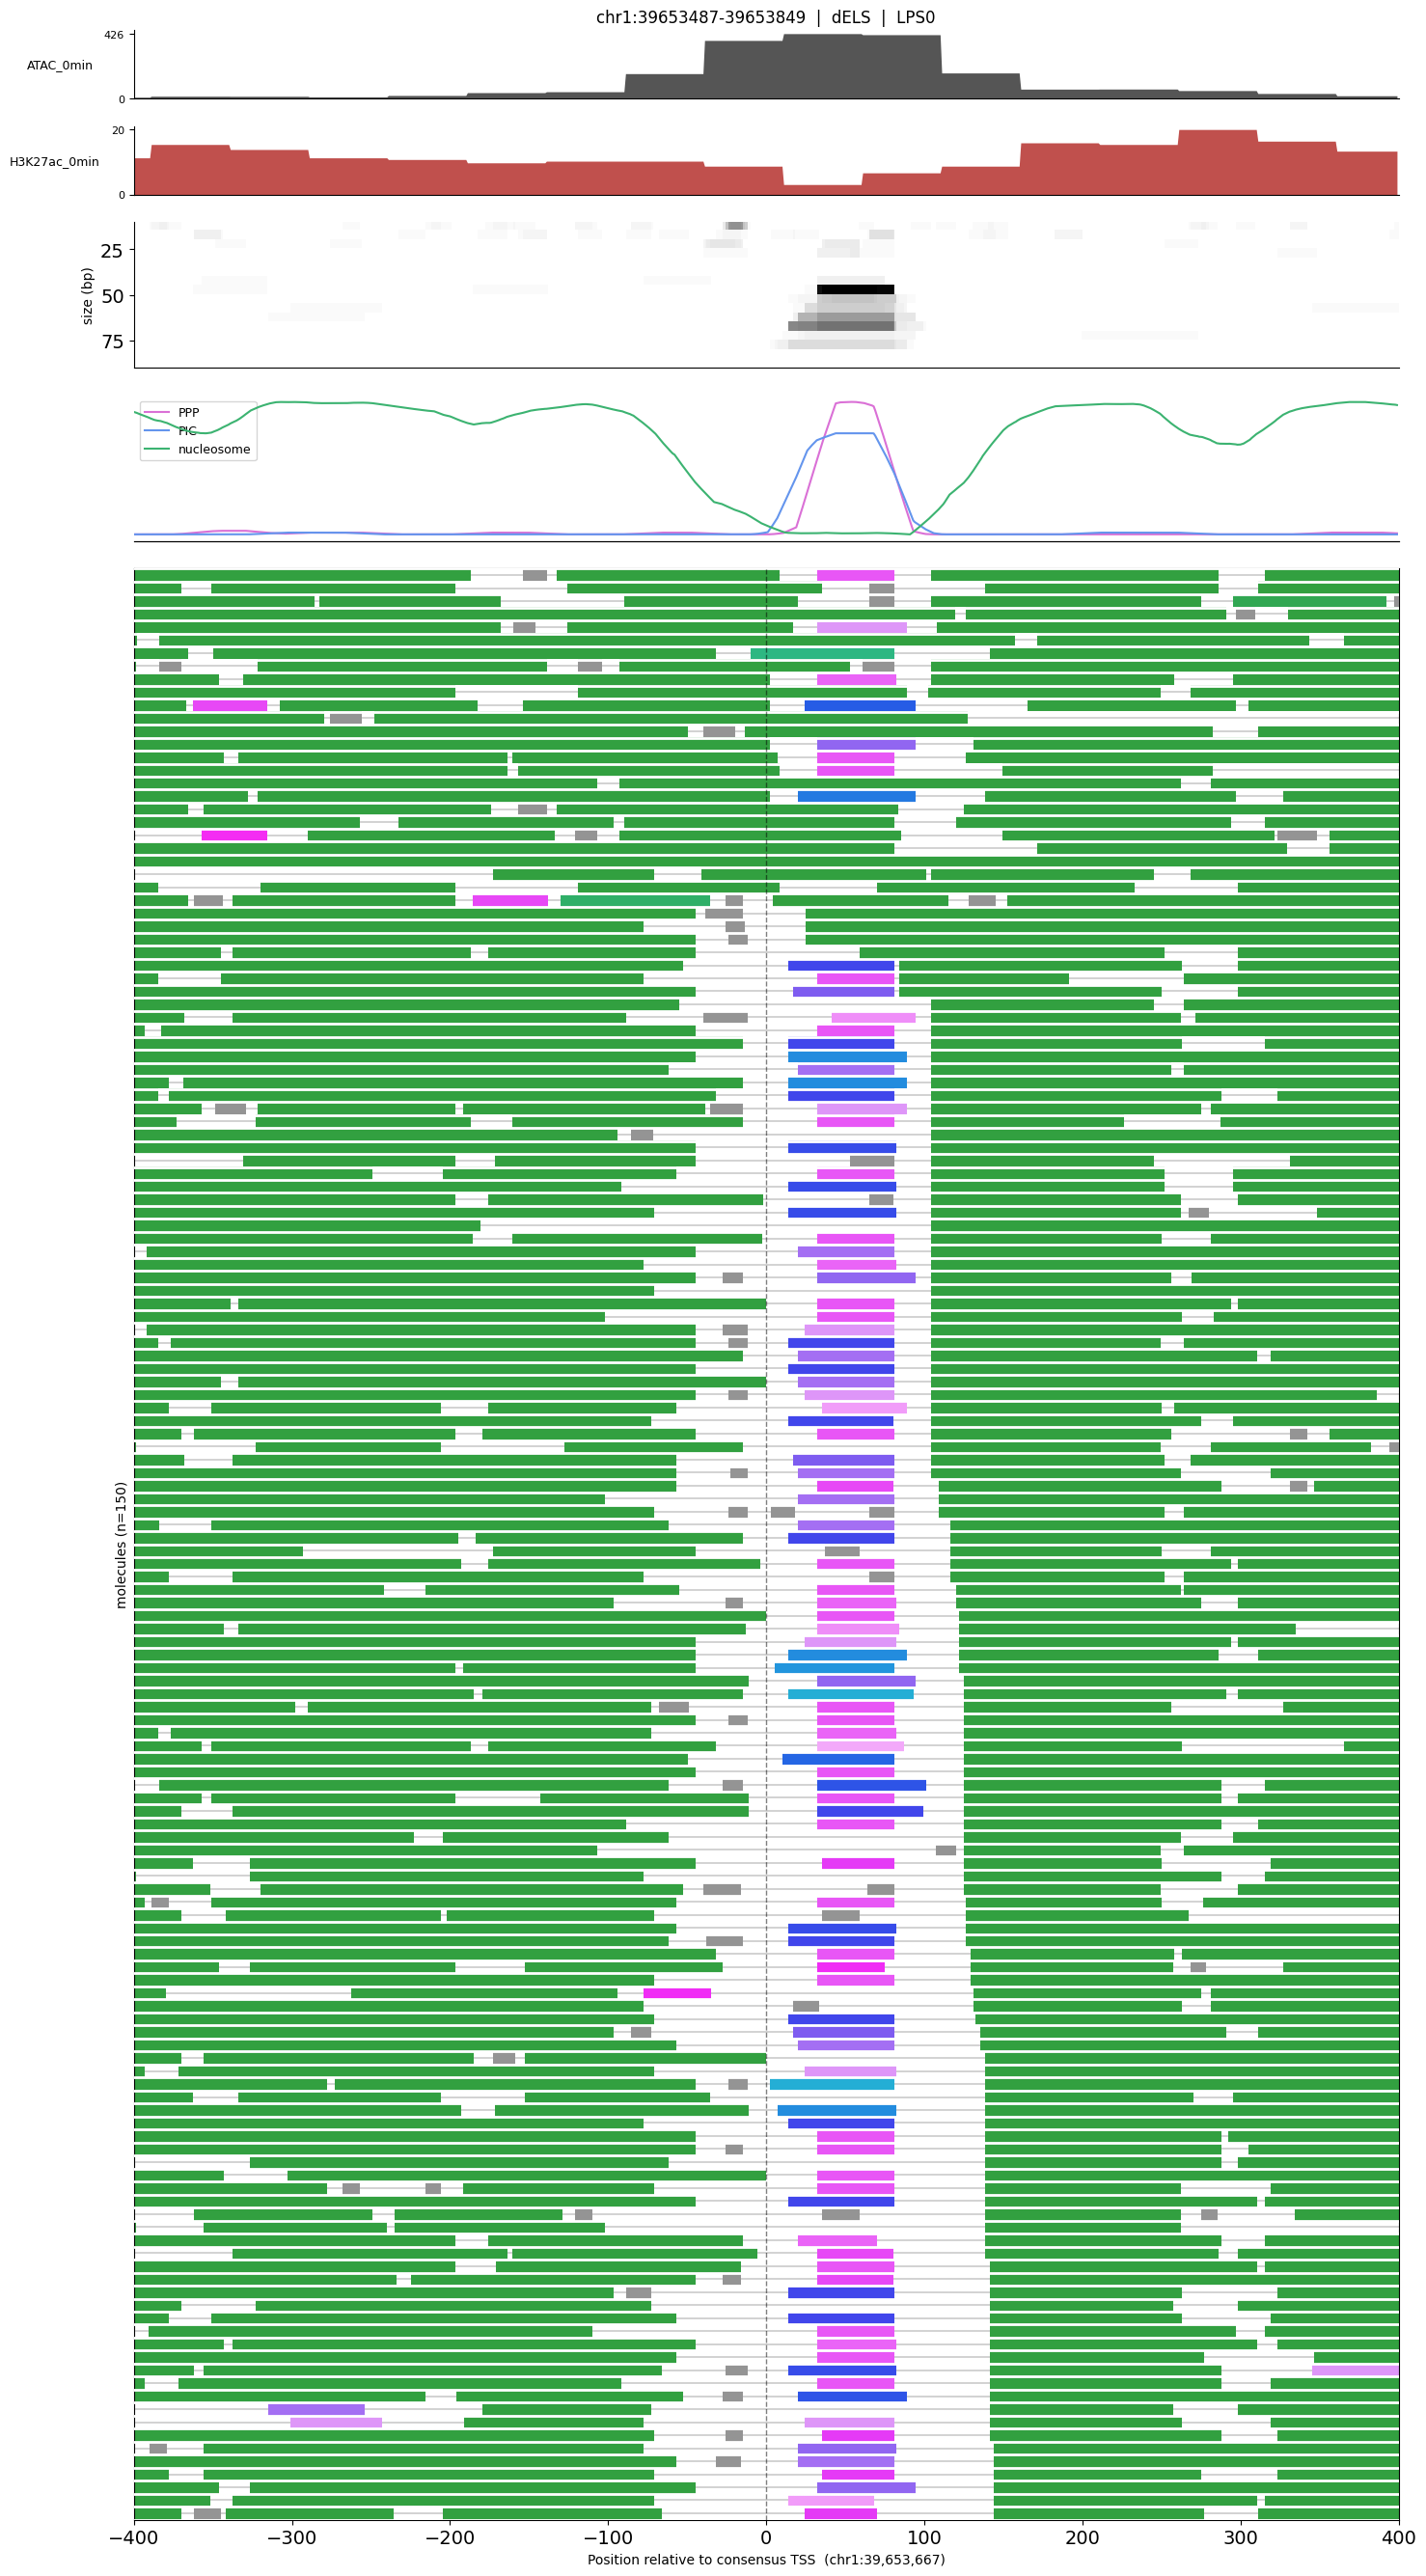

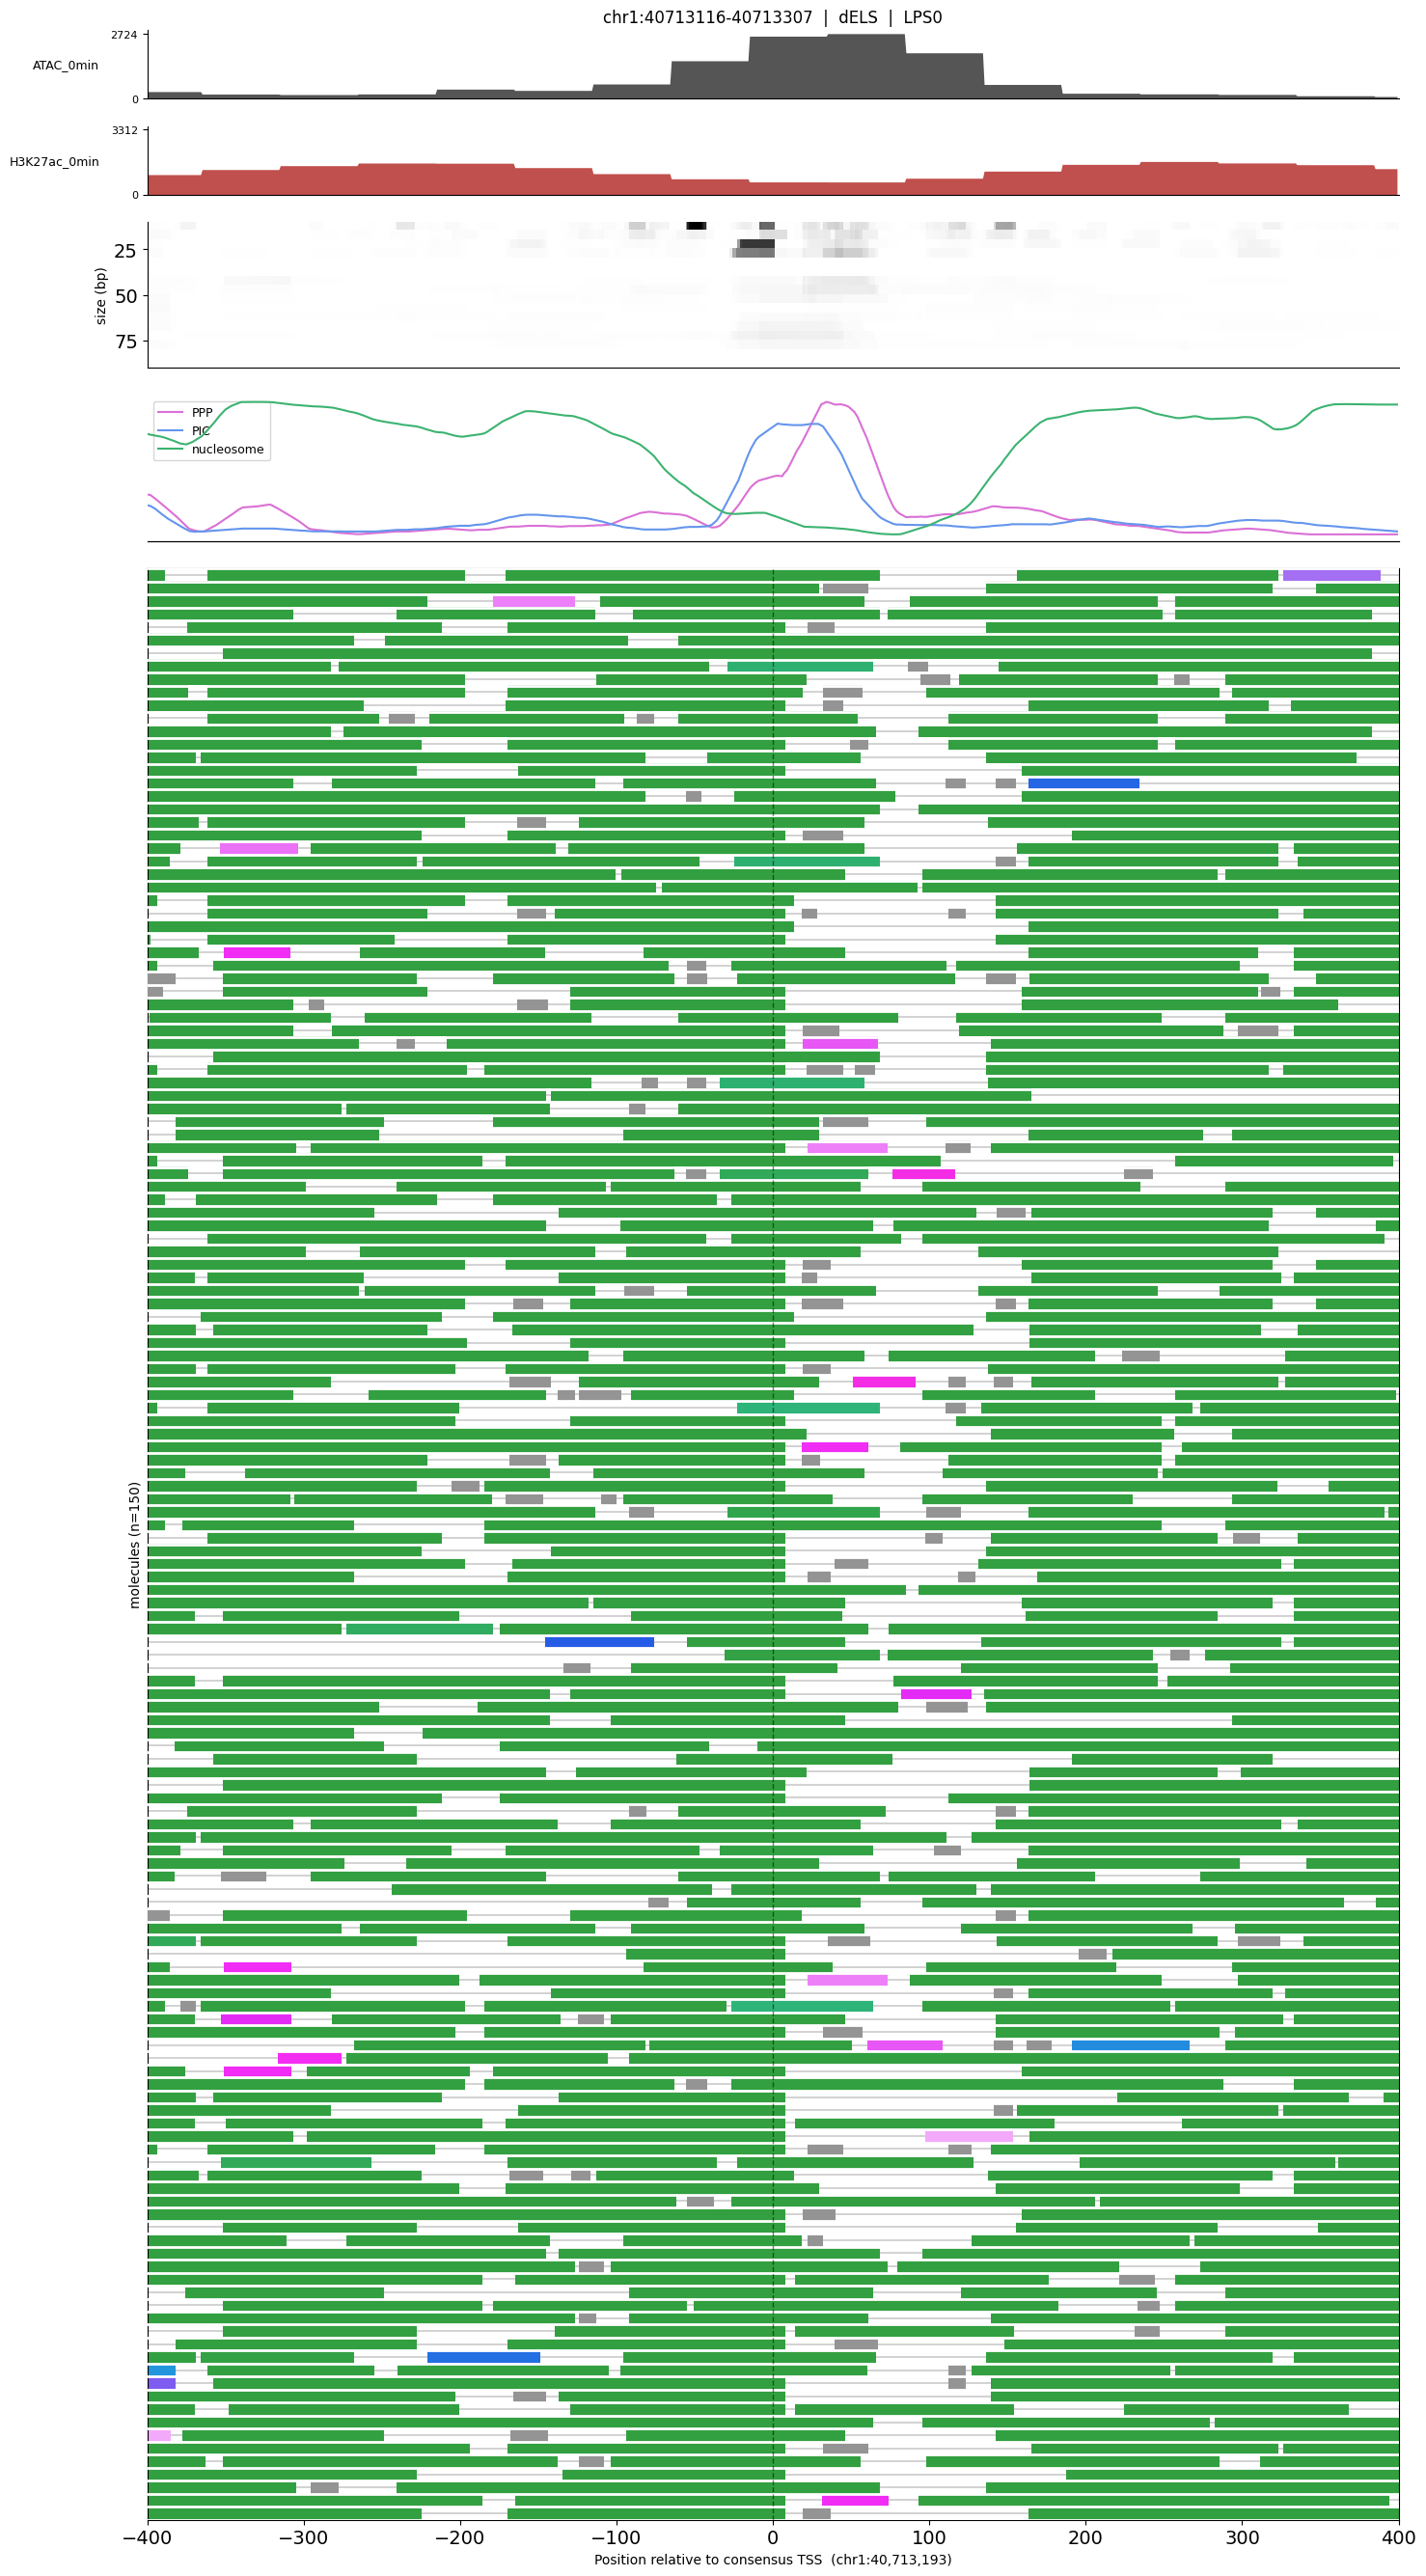

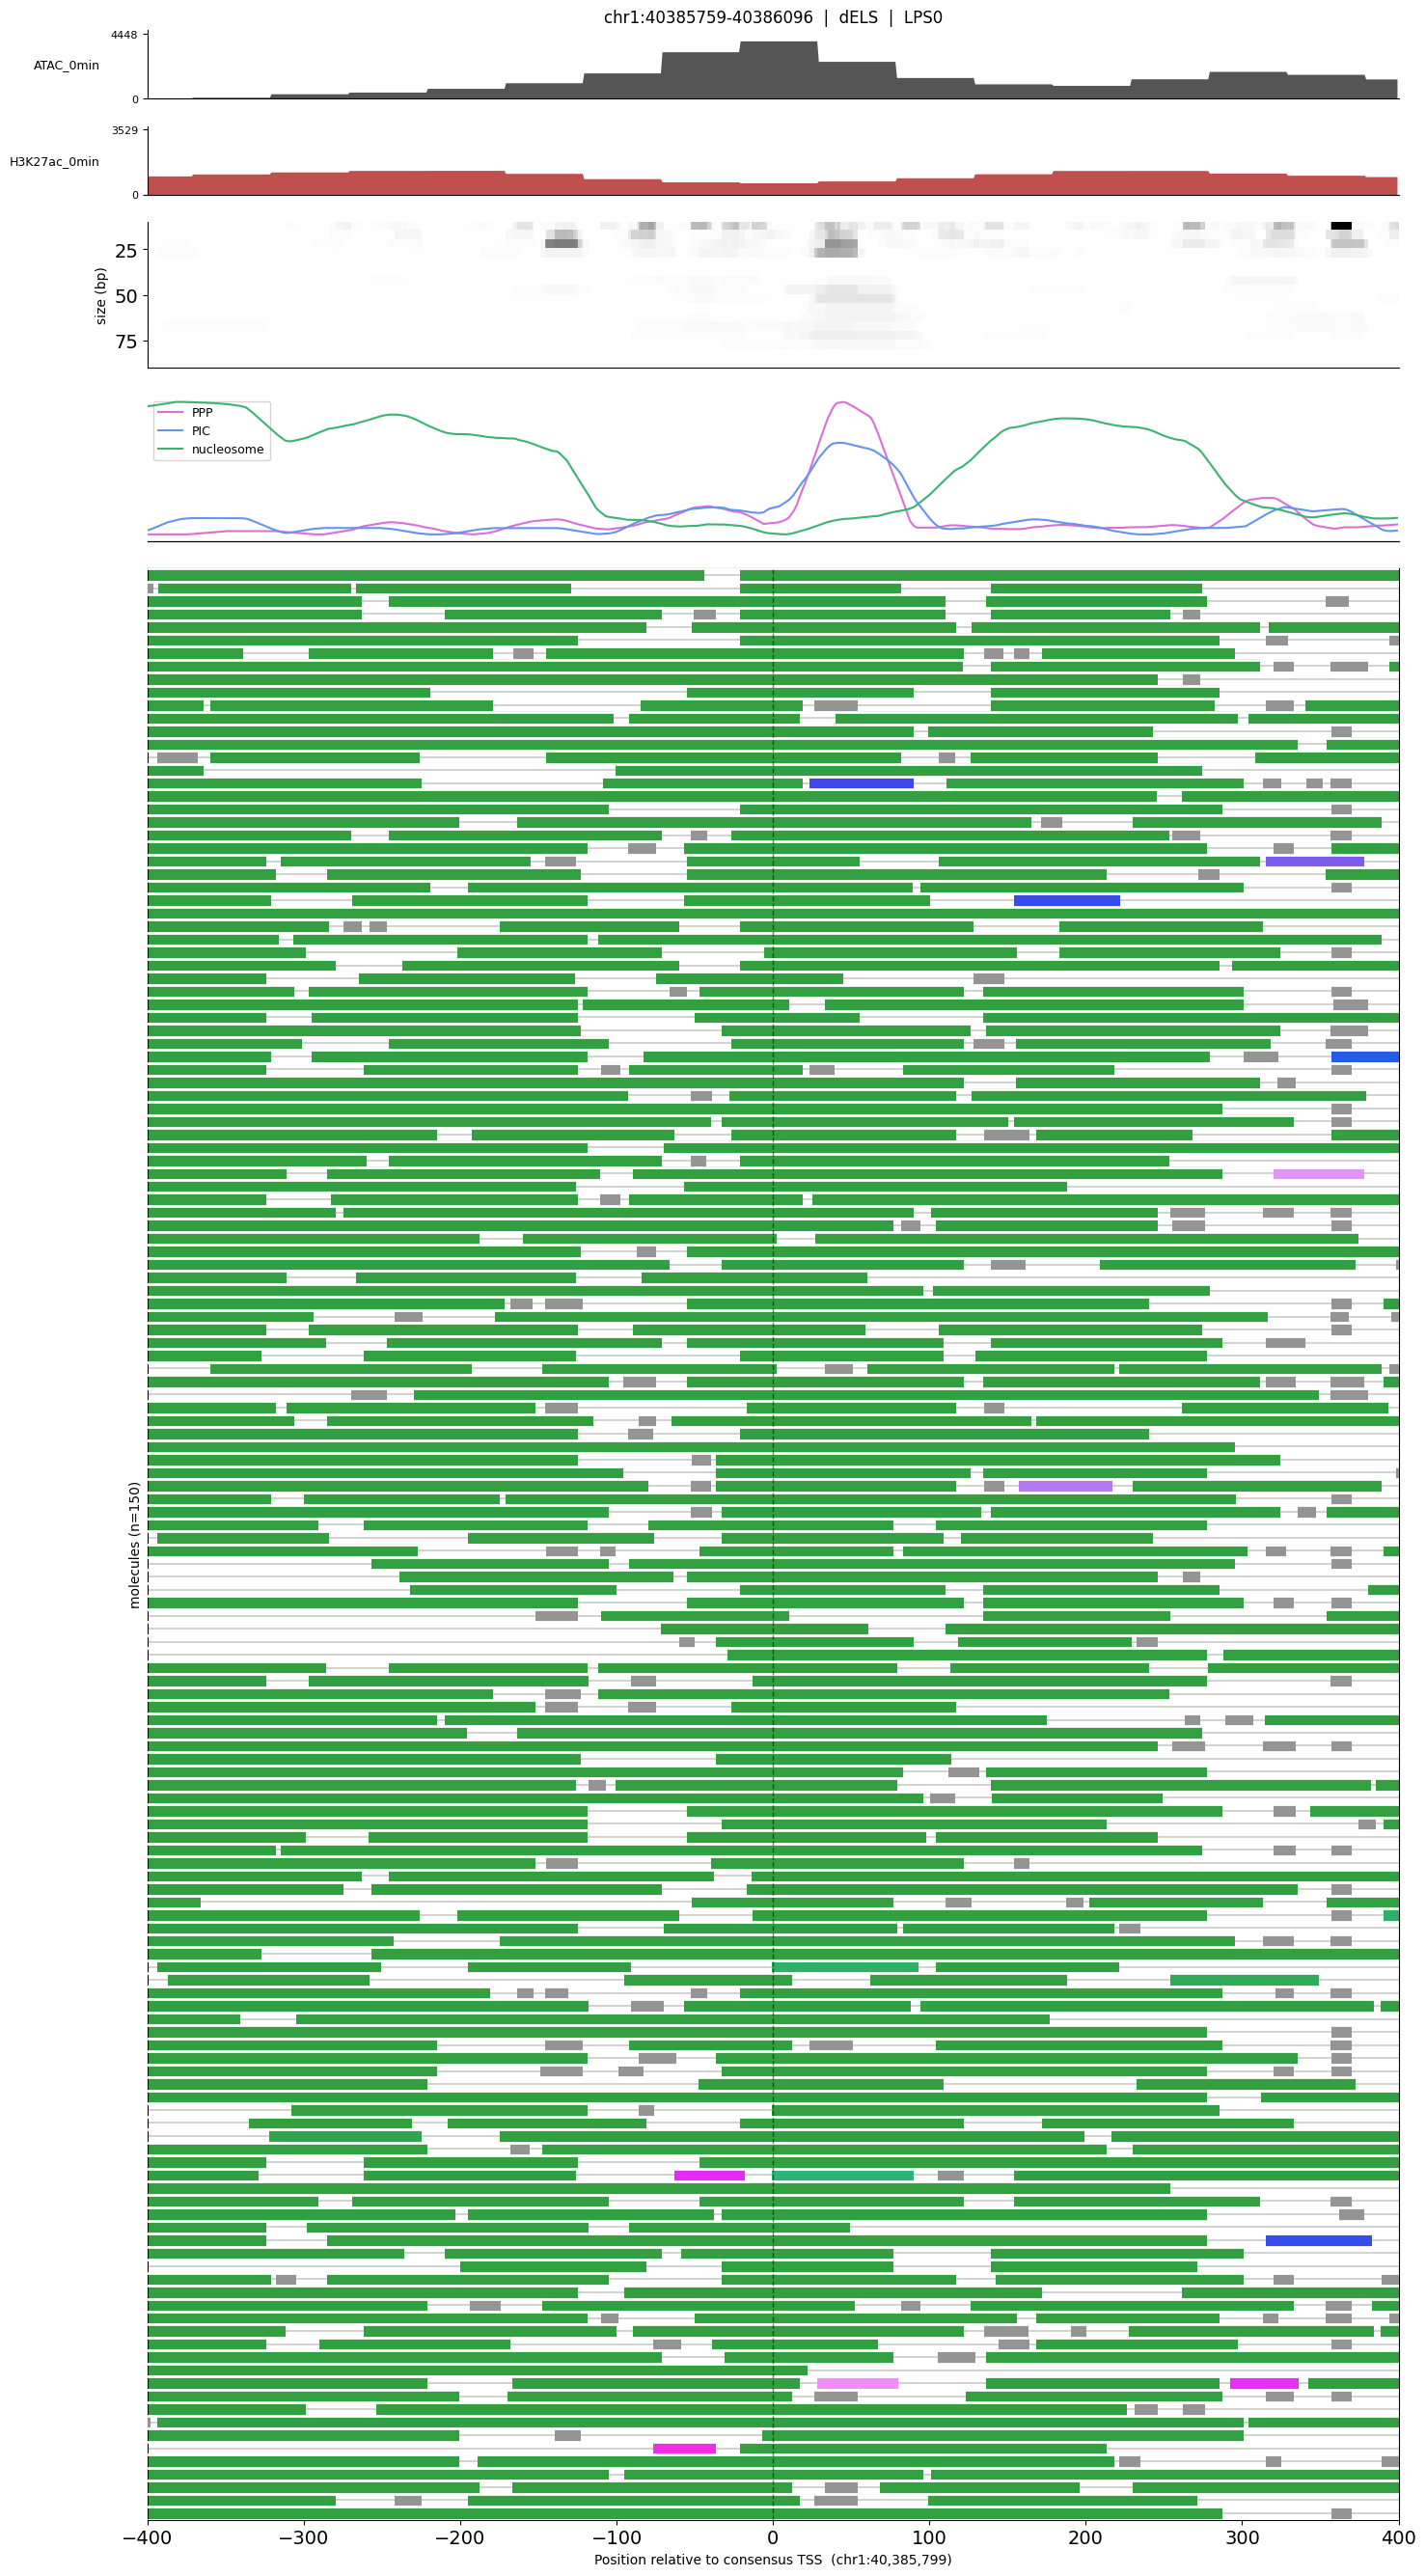

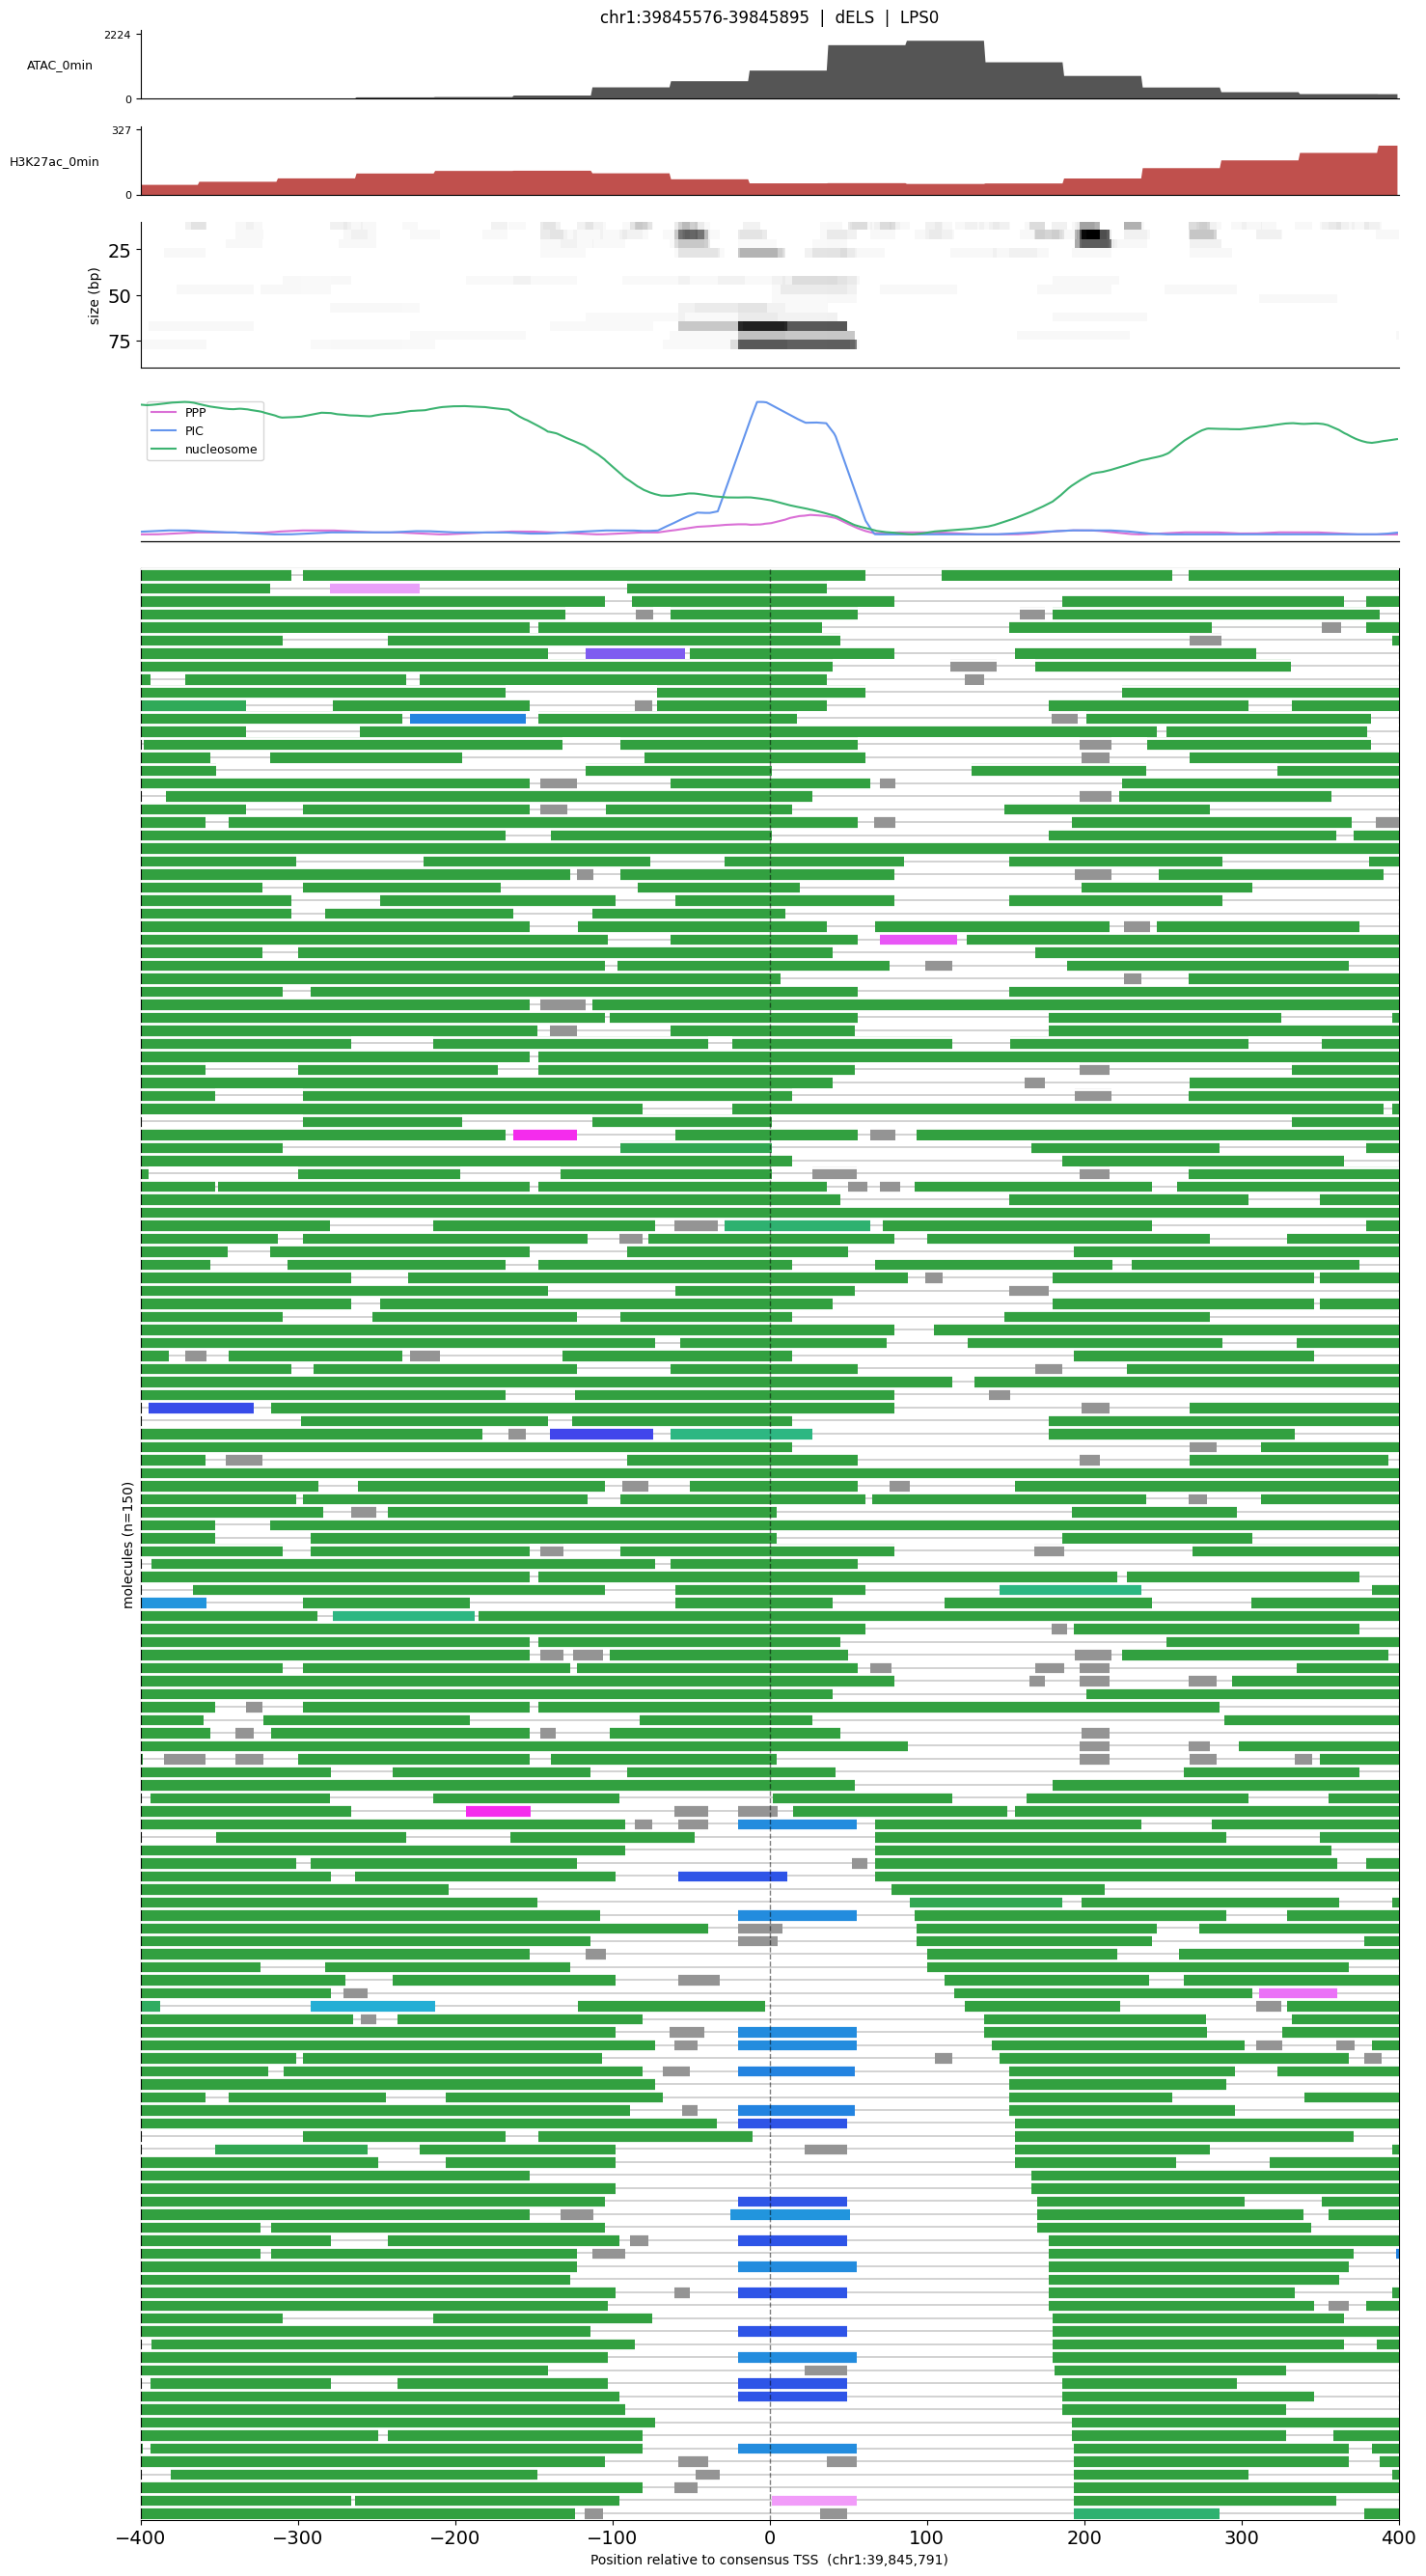

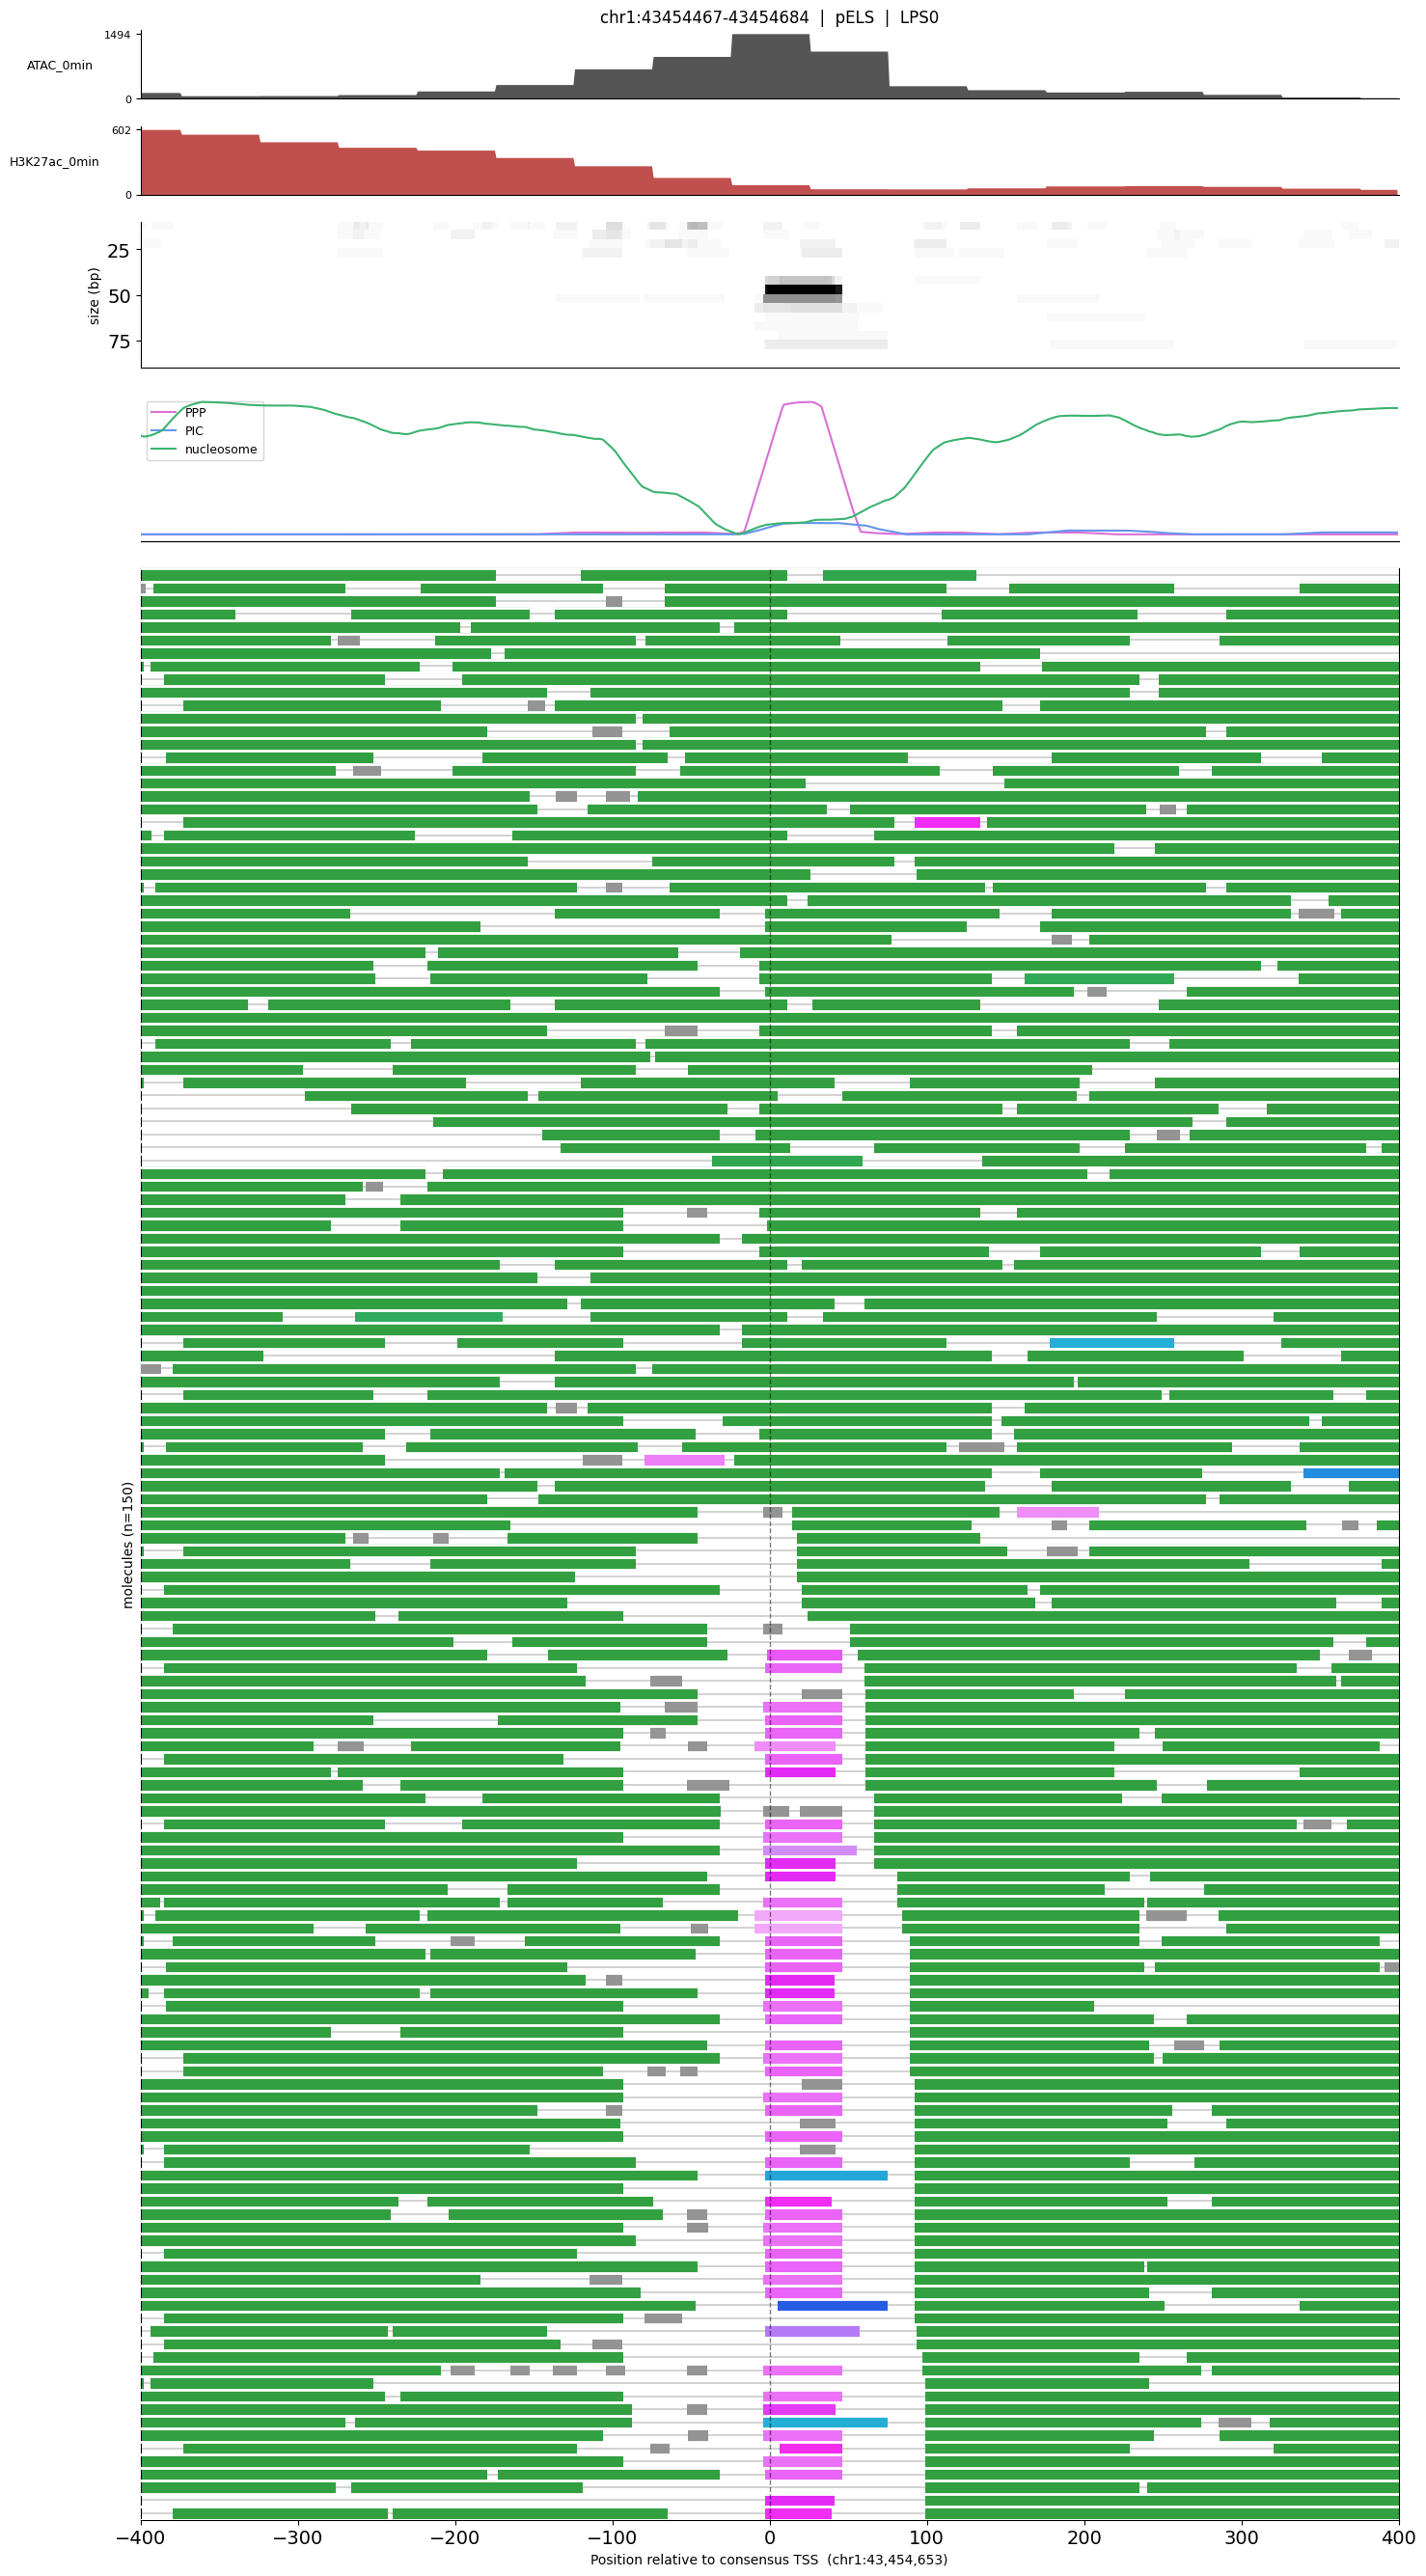

In [13]:
def locus_labels(row):
    """Plot title and file stem for either an enhancer or a promoter anchor row."""
    if "enhancer_id" in row:
        return f"{row.enhancer_id}  |  {row.encode_class}", row.enhancer_id.replace(":", "_")
    return (f"{row.gene_name}  |  {row.strand} strand  |  {row.tss_source} TSS",
            str(row.gene_name))


def plot_locus(row, window=400, smooth_width=SMOOTH, size_bin=5,
               max_reads=150, timepoint=TIMEPOINT, out_dir=None):
    """Five-panel browser plot for a single anchor (enhancer or gene promoter)."""
    label, stem = locus_labels(row)
    mat = ff.build_read_matrix(row.chrom, int(row.anchor), window + smooth_width,
                               strand=row.strand, timepoint=timepoint)
    if mat.empty:
        print(f"no reads at {label}")
        return None

    ordered = ff.order_reads_by_nucleosome(mat)
    if ordered.empty:
        print(f"no read has a downstream nucleosome at {label}")
        return None
    view = ordered.iloc[:max_reads].loc[:, [str(i) for i in range(-window, window)]]
    d = view.to_numpy()
    n_reads = d.shape[0]

    fig, ax = plt.subplots(
        5, 1, figsize=(15, n_reads / 7 + 5.5),
        gridspec_kw={"height_ratios": [0.75, 0.75, 1.6, 1.6, max(3, n_reads / 7)]},
    )

    # --- panels 0-1: public ATAC / H3K27ac at the paired public timepoint ------
    # y-limits are the max over all four paired timepoints, so the same locus is
    # directly comparable between the LPS0/LPS5/LPS10/LPS15 figures.
    x = np.arange(-window, window)
    for i, assay in enumerate(["ATAC", "H3K27ac"]):
        profs = ff.bigwig_profiles(assay, row.chrom, int(row.anchor), window,
                                   strand=row.strand)
        ymax = max(p.max() for p in profs.values()) or 1.0
        ax[i].fill_between(x, profs[timepoint], color=ff.TRACK_COLORS[assay], lw=0)
        ax[i].set_xlim(-window, window)
        ax[i].set_ylim(0, ymax * 1.05)
        ax[i].set_yticks([0, ymax])
        ax[i].set_yticklabels(["0", f"{ymax:.0f}"], fontsize=8)
        ax[i].set_ylabel(ff.public_track_label(assay, timepoint), fontsize=9,
                         rotation=0, ha="right", va="center", labelpad=8)
        ax[i].set_xticks([])
        ax[i].spines["top"].set_visible(False)
        ax[i].spines["right"].set_visible(False)

    # --- panel 2: footprint size x position density at this locus -------------
    dens = ff.size_position_density(mat, -window, window, ff.TF_RANGE[0], ff.NUC_MIN_SIZE,
                                    size_bin)
    cov = np.maximum(
        ff.slice_positions(mat, -window, window).ne(ff.NOT_COVERED).sum(axis=0).to_numpy(), 1
    )
    ax[2].imshow(dens.to_numpy() / cov * 100, cmap="gray_r", aspect="auto",
                 interpolation="nearest", rasterized=True,
                 extent=[-window, window, ff.NUC_MIN_SIZE, ff.TF_RANGE[0]])
    ax[2].set_ylabel("size (bp)", fontsize=10)
    ax[2].set_xticks([])
    ax[2].spines["top"].set_visible(False)
    ax[2].spines["right"].set_visible(False)

    # --- panel 3: PPP / PIC / nucleosome enrichment ---------------------------
    ax2 = ax[3].twinx()
    lines = []
    for name, rng, axis in [
        ("PPP", ff.PPP_RANGE, ax[3]),
        ("PIC", ff.PIC_RANGE, ax[3]),
        ("nucleosome", ff.NUC_RANGE, ax2),
    ]:
        prof = ff.smooth(
            ff.meta_line_plot(mat, -window - smooth_width, window + smooth_width, *rng),
            smooth_width,
        ) * 100
        lines += axis.plot(np.arange(-window, window), prof,
                           color=ff.LINE_COLORS[name], label=name)
    ax[3].set_xlim(-window, window)
    ax2.set_xlim(-window, window)
    ax[3].legend(lines, [l.get_label() for l in lines], loc="upper left", fontsize=9)
    ax[3].set_xticks([])
    ax[3].set_yticks([])
    ax2.set_yticks([])
    for a in (ax[3], ax2):
        for side in ("top", "right", "left"):
            a.spines[side].set_visible(False)

    # --- panel 4: single molecules --------------------------------------------
    extent = [-window, window, n_reads, 0]
    for i in range(n_reads):                       # accessible fibre backbone
        ax[4].axhline(i + 0.5, color="black", lw=0.25, zorder=1)
    ax[4].imshow(d, cmap=ff.POL_CP, vmin=0, vmax=100, aspect="auto",
                 interpolation="nearest", rasterized=True, extent=extent, zorder=2)
    ax[4].imshow(ff.mask_layer(view).to_numpy(), cmap=ff.MASK_CP, vmin=0, vmax=1000,
                 aspect="auto", interpolation="nearest", rasterized=True,
                 extent=extent, zorder=3)
    for i in range(n_reads + 1):                   # white separators between reads
        ax[4].axhline(i, color="white", lw=2, zorder=4)
    ax[4].axvline(0, color="black", lw=1, ls="--", alpha=0.5, zorder=5)
    ax[4].set_xlim(-window, window)
    ax[4].set_ylim(n_reads, 0)
    ax[4].set_yticks([])
    ax[4].set_ylabel(f"molecules (n={n_reads})", fontsize=10)
    ax[4].set_xlabel(f"Position relative to consensus TSS  ({row.chrom}:{int(row.anchor):,})",
                     fontsize=10)

    ax[0].set_title(f"{label}  |  {timepoint}", fontsize=12)
    plt.tight_layout()
    if out_dir:
        plt.savefig(f"{out_dir}/{stem}_{timepoint}.pdf", bbox_inches="tight")
    plt.show()
    return view


loci_dir = f"{OUT_DIR}/plots/example_loci"
os.makedirs(loci_dir, exist_ok=True)

for _, row in candidates.head(5).iterrows():
    plot_locus(row, out_dir=loci_dir)

## 3b. Single-locus view for a named gene

The same five-panel plot, anchored on a gene instead of an enhancer. The TSS is
the THP-1 dominant CAGE peak where the gene has one and the GENCODE TSS
otherwise (`tss_source` says which). Minus-strand genes are flipped so positive
offsets are always downstream - the public tracks are flipped with them.

`GENE_TIMEPOINTS` controls which LPS timepoints are drawn: one figure per
timepoint, each saved as `<GENE>_<timepoint>.pdf`, so an inducible gene can be
followed across the LPS response. Each figure carries the public ATAC and
H3K27ac track for the timepoint paired with it (LPS0 -> 0 min, LPS5 -> 30 min,
LPS10 -> 60 min, LPS15 -> 90 min). Fiber-seq read depth differs between
timepoints, so the molecule counts in the bottom panel are not directly
comparable - compare the *pattern* (NDR width, where PPP and PIC sit) rather
than the row count. The public tracks do share a y-axis across timepoints, so
their heights are comparable.

**Check `tss_source` before reading a gene plot.** Only 9,182 of the 20,121
protein-coding genes get a CAGE anchor; the rest fall back to the GENCODE gene
start, which is the 5'-most end of the *extended* gene model and can sit far
from the real dominant promoter. ACTB is the clearest example: GENCODE v49
models it as chr7:5,526,409-5,563,902, so its fallback TSS lands ~33 kb away
from the actual promoter, whose CAGE peak (63,767 tags at chr7:5,530,600) was
assigned to the neighbouring gene by the nearest-gene rule in the FANTOM5
consensus build. Genes with `tss_source == "cage"` are centred correctly.

TNF  chr6:31,575,567  strand +  TSS from cage


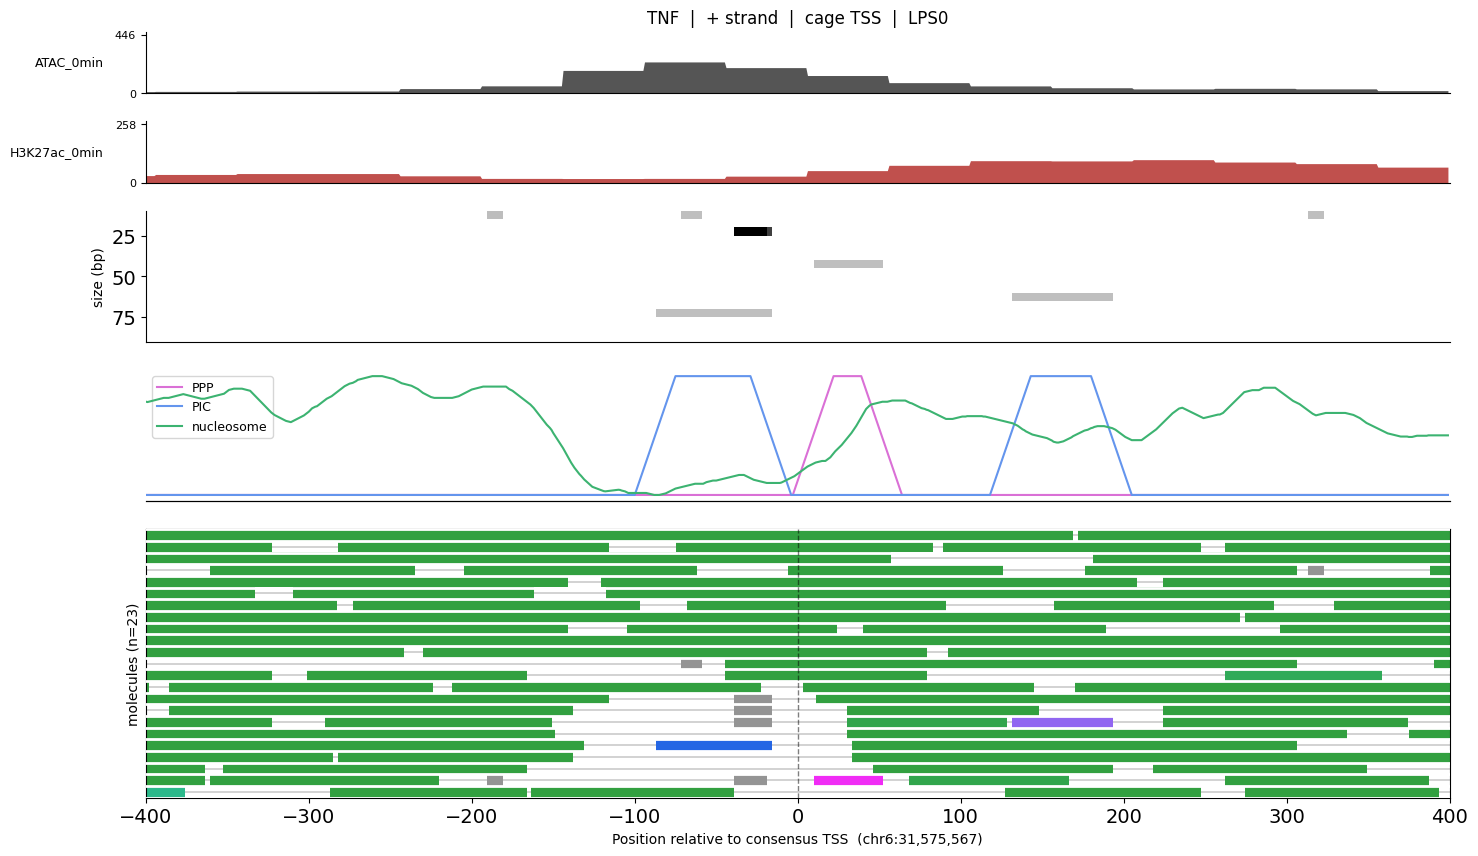

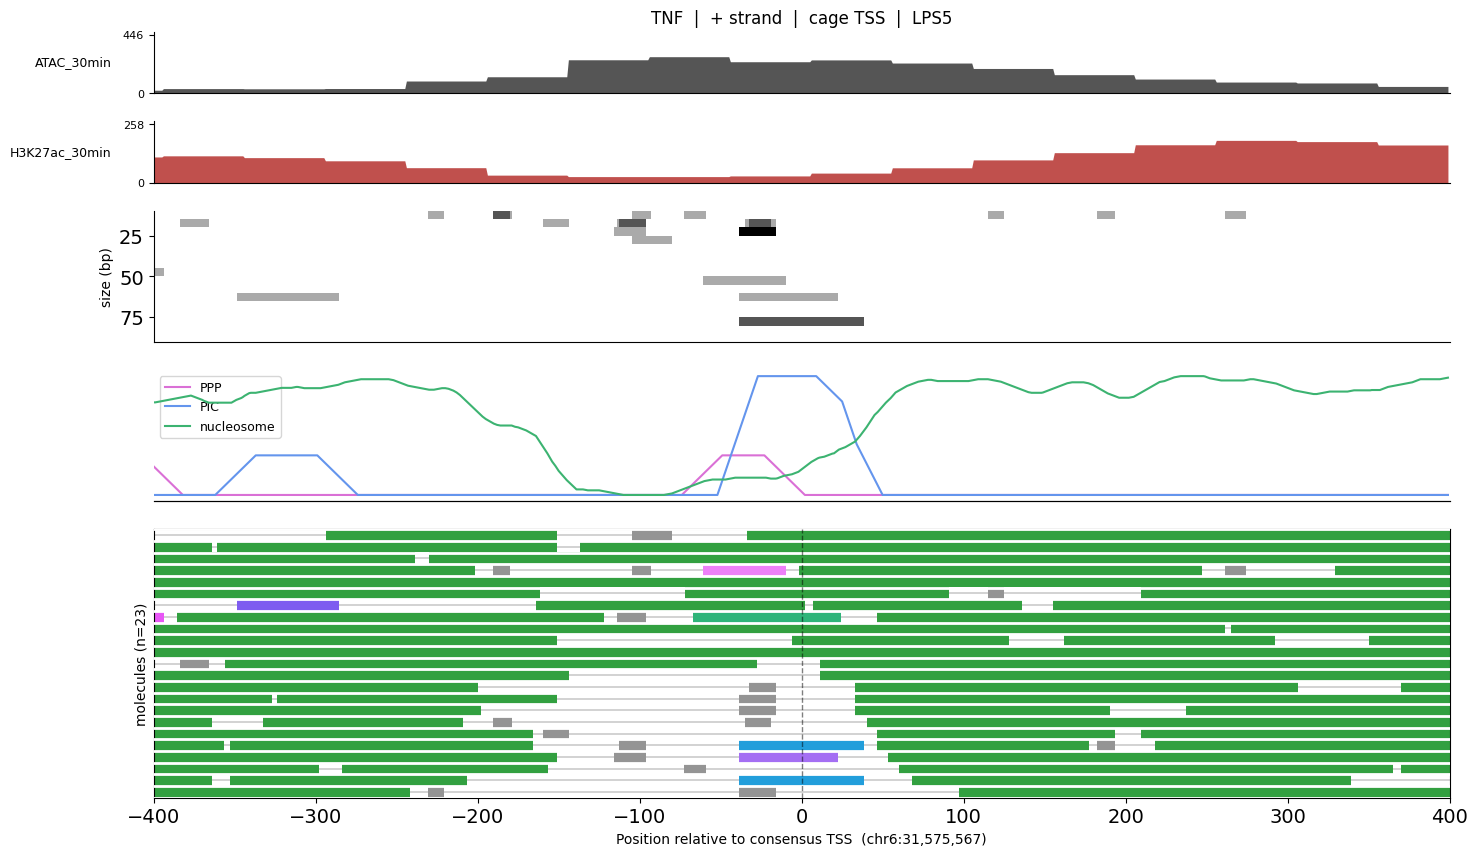

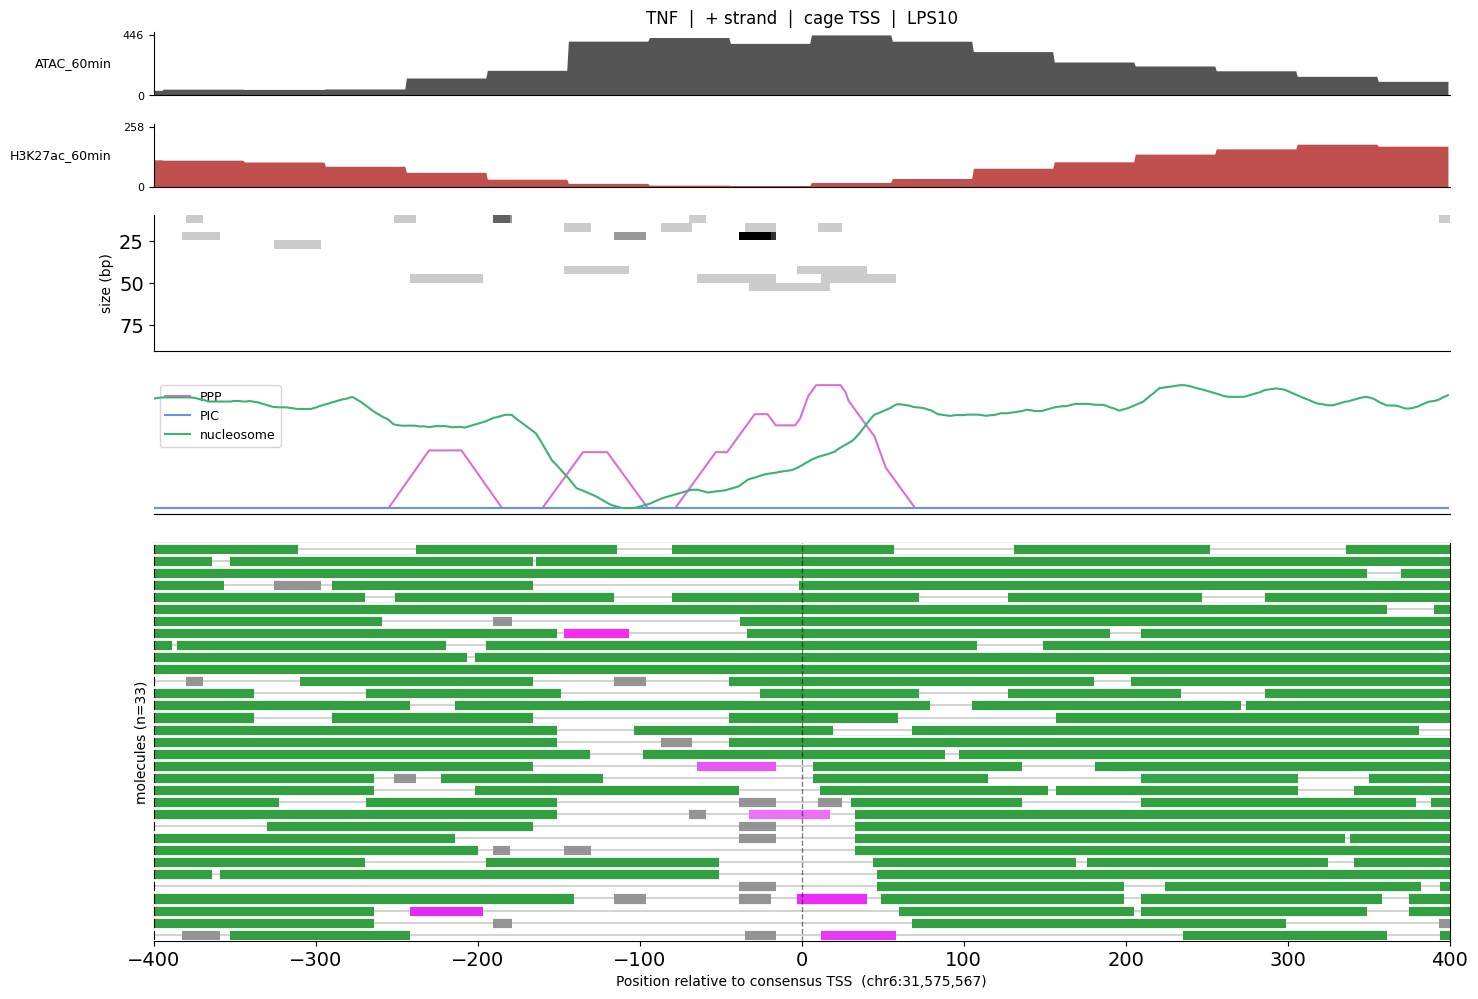

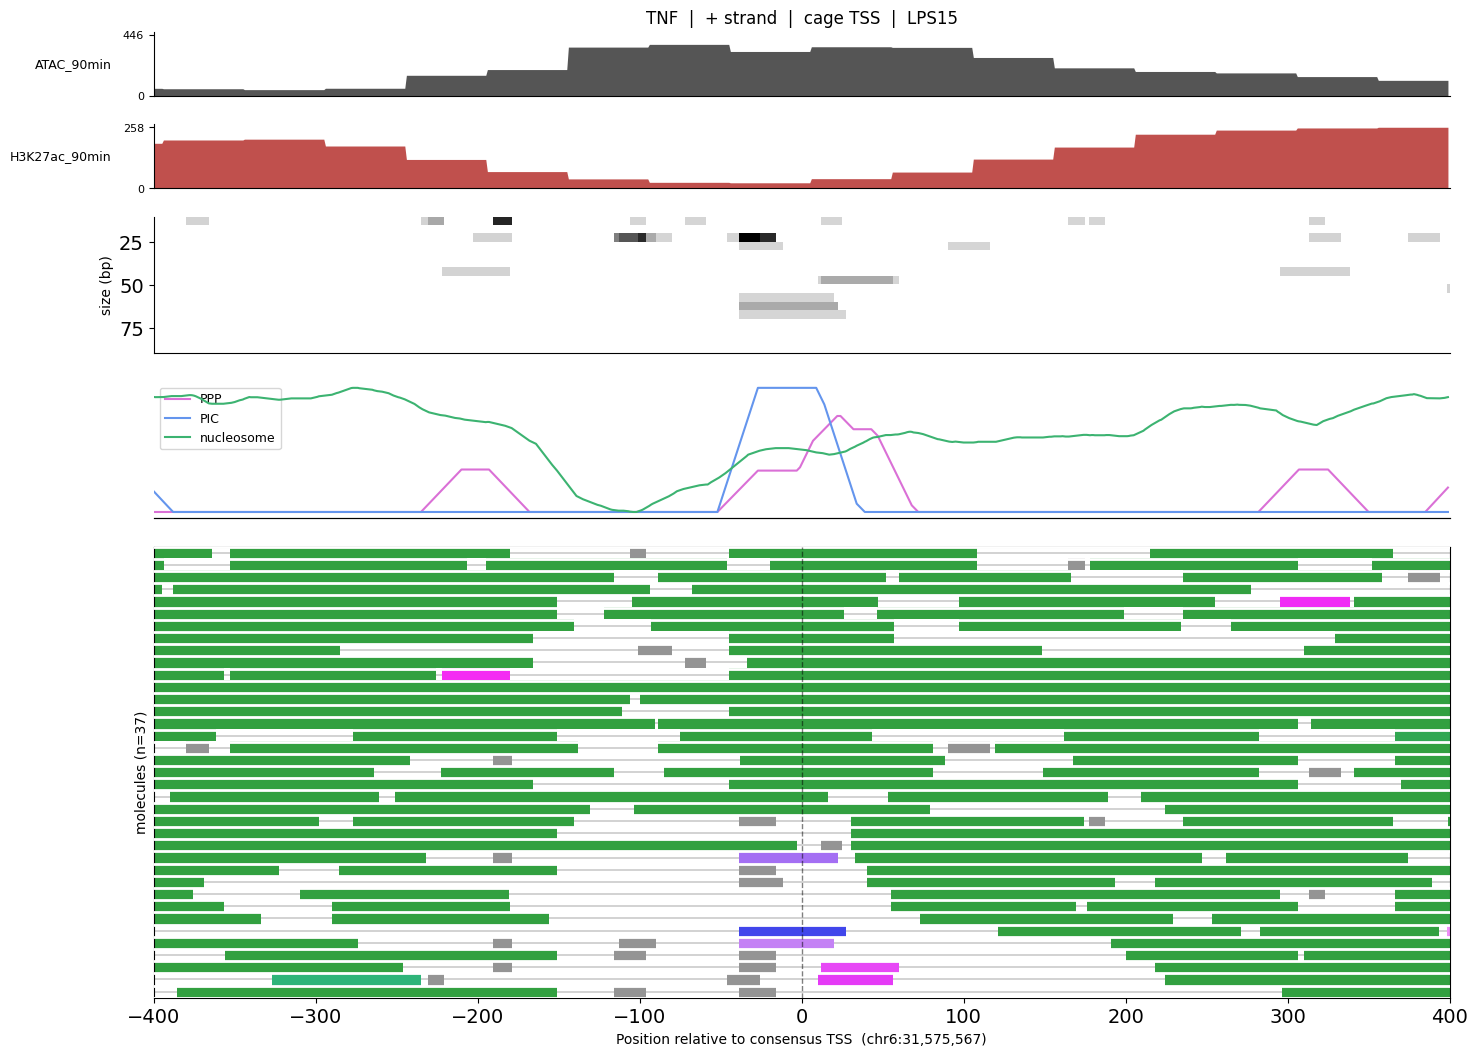

In [14]:
GENE = "TNF"        # other LPS-response genes: TNF, IL6, CXCL2, PTGS2, RELB
NEARBY_KB = 10       # also plot enhancer anchors within this distance of the TSS
GENE_TIMEPOINTS = ["LPS0", "LPS5", "LPS10", "LPS15"]   # set to [TIMEPOINT] for just one

promoters = ff.load_promoter_anchors()
hit = promoters[promoters.gene_name == GENE]
if hit.empty:
    raise ValueError(f"{GENE} not found in the promoter anchor table")
gene = hit.iloc[0]
print(f"{GENE}  {gene.chrom}:{int(gene.anchor):,}  strand {gene.strand}  "
      f"TSS from {gene.tss_source}")

for tp in GENE_TIMEPOINTS:
    plot_locus(gene, timepoint=tp, out_dir=loci_dir)

### Enhancer anchors near that gene

These are the enhancer-promoter pairs the coupling notebook tests, viewed one
molecule at a time. Reads long enough to cover both anchors carry the enhancer
and the promoter state on the same fibre.

1 enhancer anchors within 10 kb of the TNF TSS


,chrom,anchor,enhancer_id,encode_class,dnase,distance_to_tss
34766,chr6,31568794,chr6:31568445-31569126,dELS,1,-6773


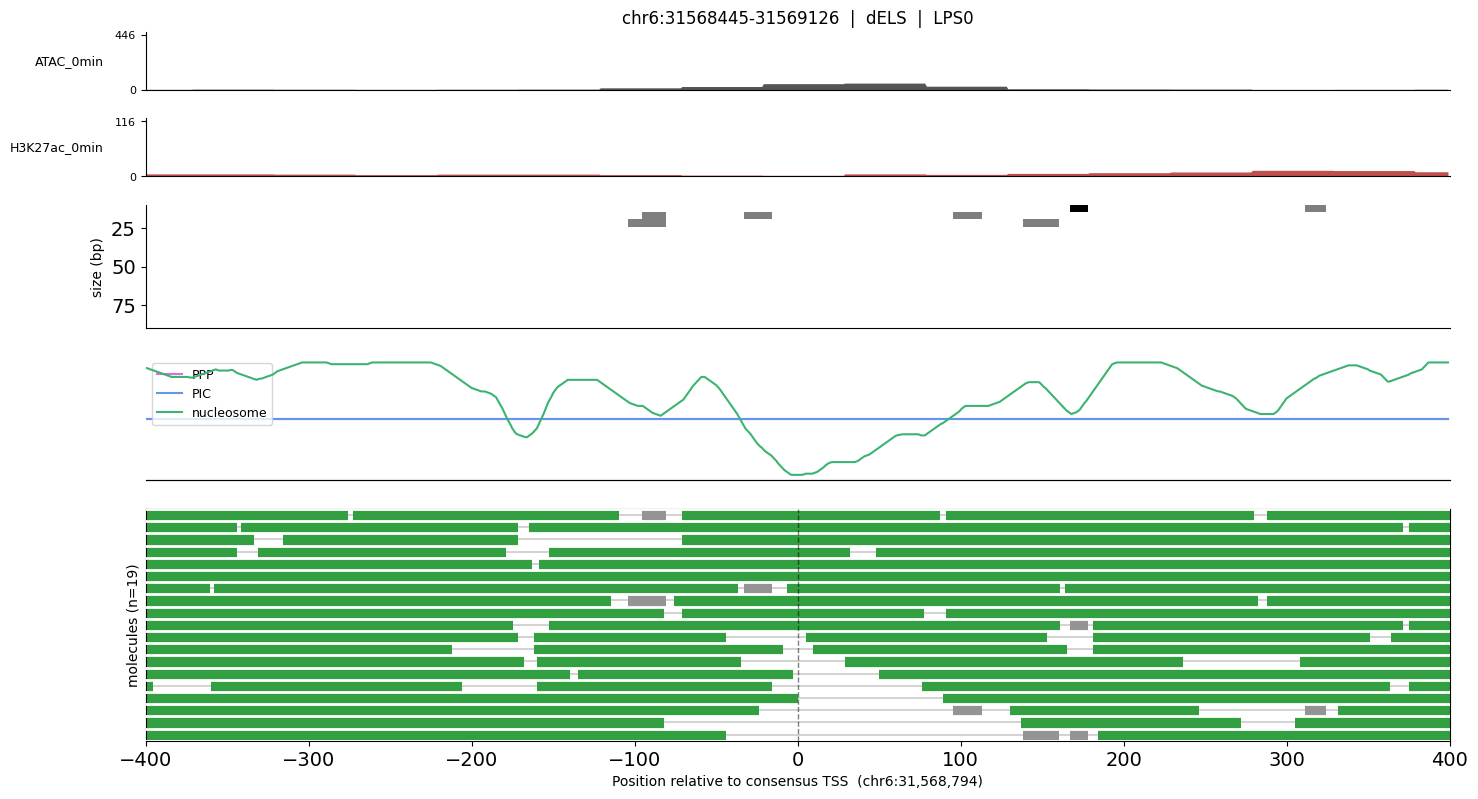

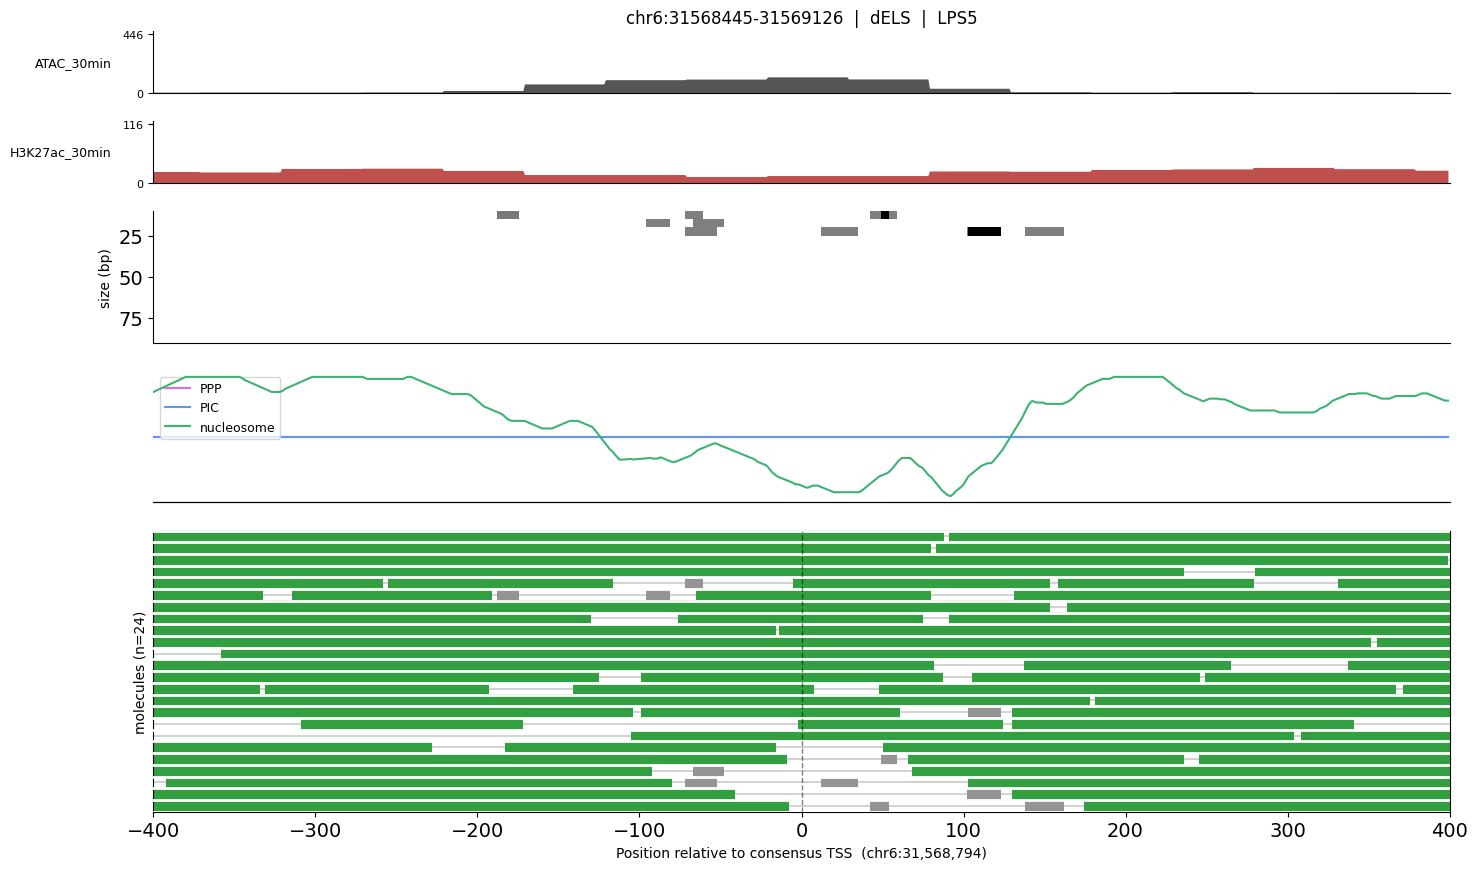

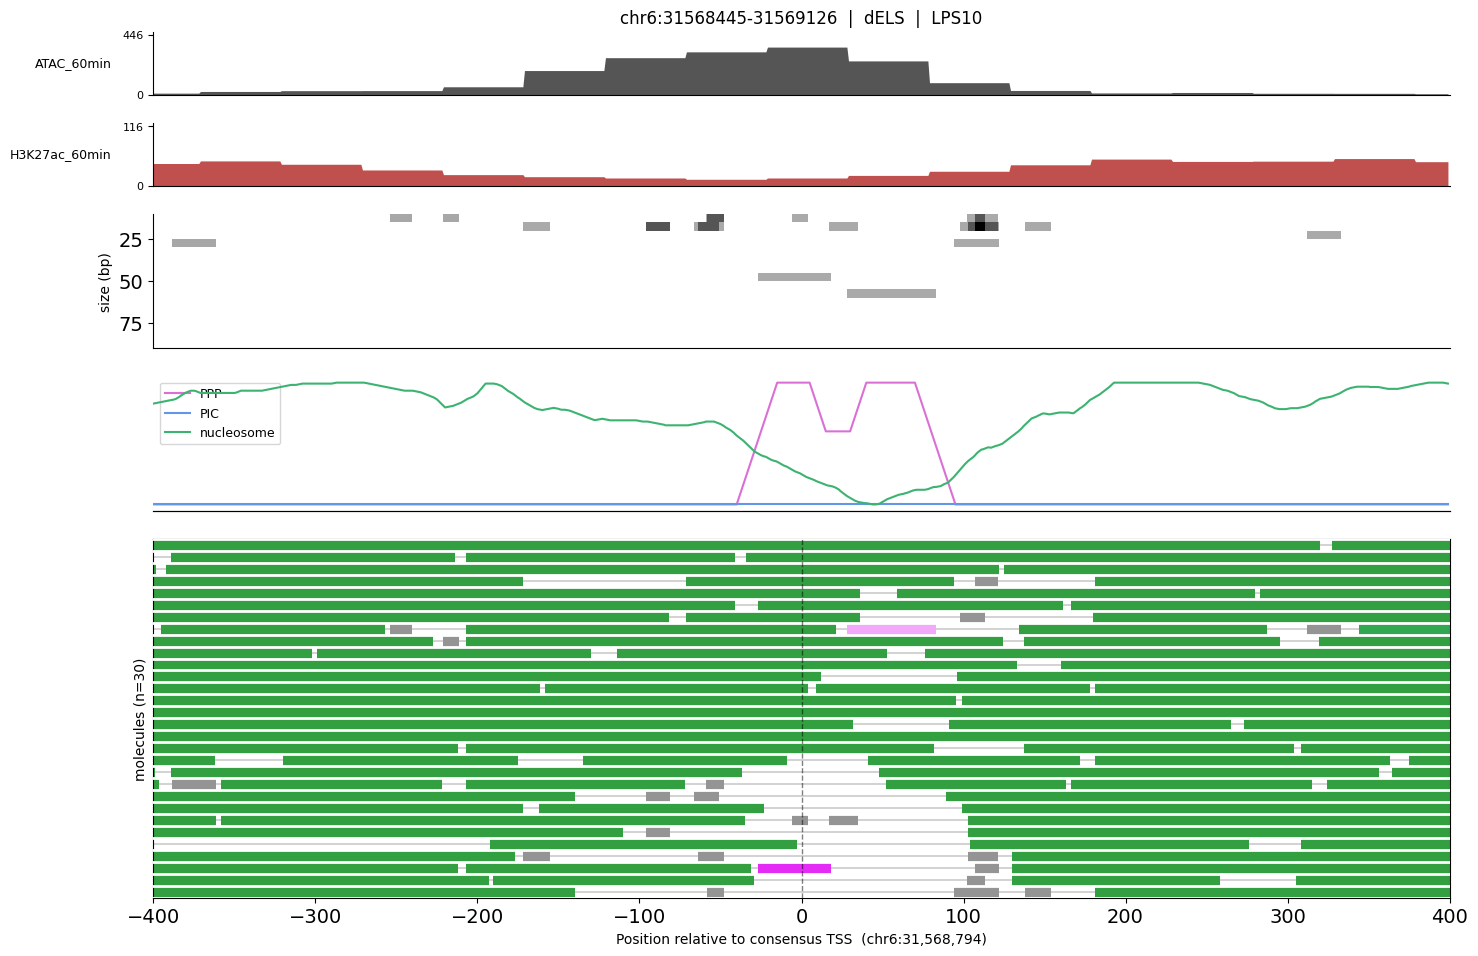

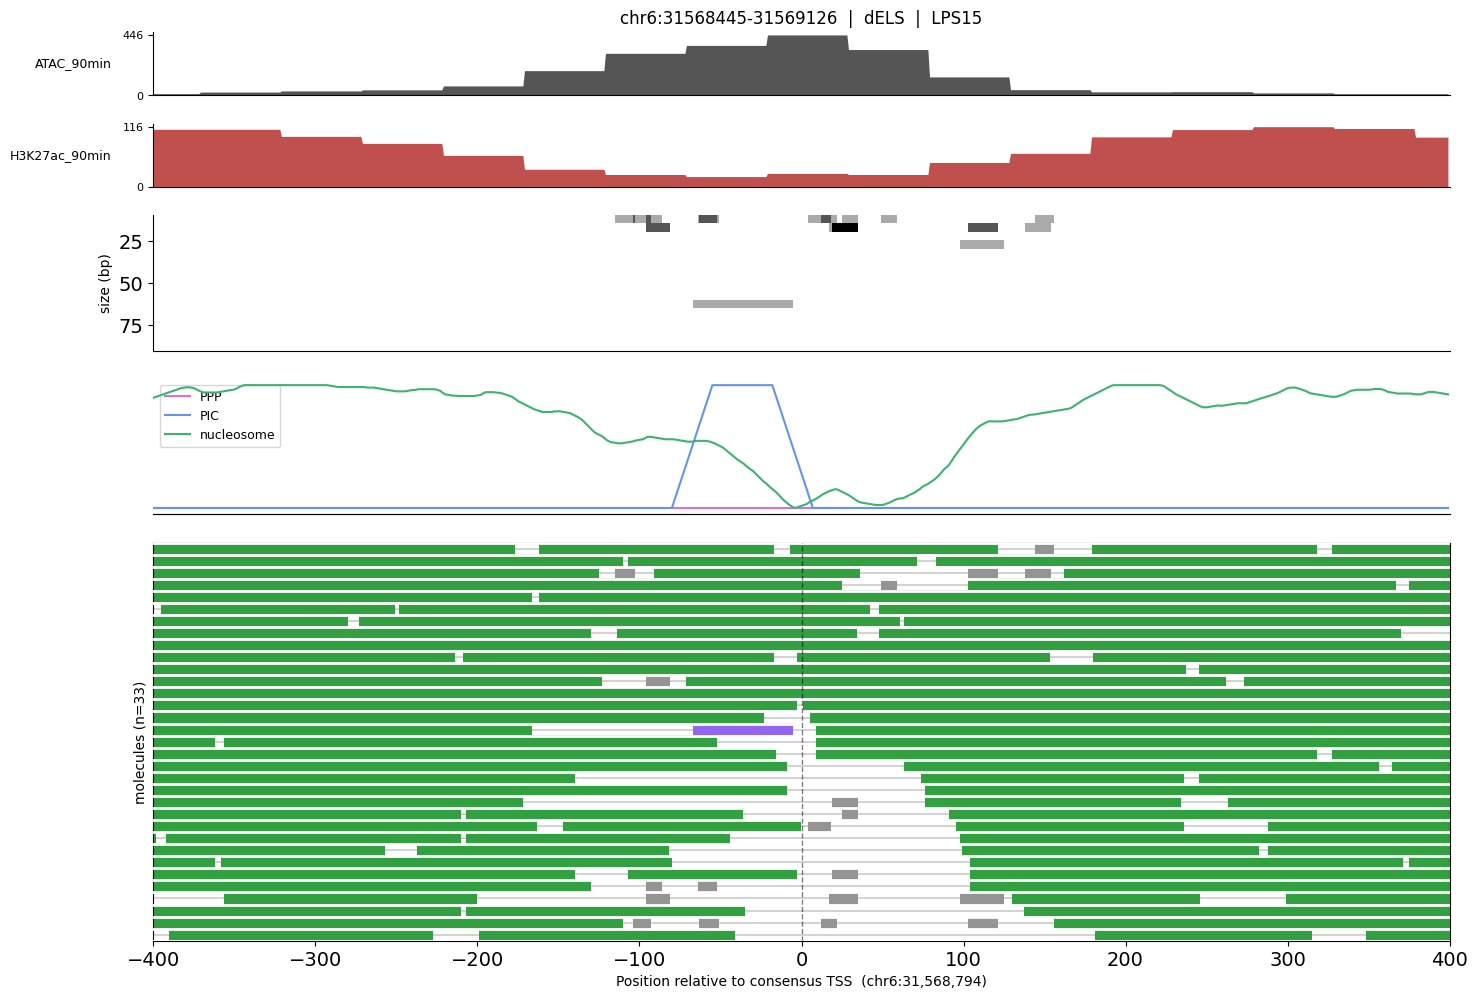

In [15]:
nearby = enhancers[
    (enhancers.chrom == gene.chrom)
    & ((enhancers.anchor - gene.anchor).abs() < NEARBY_KB * 1000)
].copy()
nearby["distance_to_tss"] = nearby.anchor - gene.anchor
print(f"{len(nearby)} enhancer anchors within {NEARBY_KB} kb of the {GENE} TSS")
display(nearby[["chrom", "anchor", "enhancer_id", "encode_class", "dnase",
                "distance_to_tss"]].sort_values("distance_to_tss"))

for _, row in nearby.iterrows():
    for tp in GENE_TIMEPOINTS:
        plot_locus(row, timepoint=tp, out_dir=loci_dir)

## 4. Save the accumulated profiles

The metaprofiles are written out so the coupling notebook and any downstream
figure work can reuse them without re-sweeping the anchors.

In [16]:
profiles = pd.DataFrame({
    "offset": np.arange(-WINDOW, WINDOW),
    "coverage": acc_all["coverage"],
    "ppp": class_profile(acc_all, *ff.PPP_RANGE),
    "pic": class_profile(acc_all, *ff.PIC_RANGE),
    "nucleosome": class_profile(acc_all, *ff.NUC_RANGE),
})
for name, acc in acc_strata.items():
    key = name.replace("+", "pos").replace("-", "neg")
    profiles[f"ppp_{key}"] = class_profile(acc, *ff.PPP_RANGE)
    profiles[f"pic_{key}"] = class_profile(acc, *ff.PIC_RANGE)
    profiles[f"nucleosome_{key}"] = class_profile(acc, *ff.NUC_RANGE)

os.makedirs(f"{OUT_DIR}/tables", exist_ok=True)
profiles.to_csv(f"{OUT_DIR}/tables/enhancer_metaprofiles_{TIMEPOINT}.tsv",
                sep="\t", index=False)
candidates.to_csv(f"{OUT_DIR}/tables/enhancer_read_counts_{TIMEPOINT}.tsv",
                  sep="\t", index=False)
print(f"wrote {OUT_DIR}/tables/enhancer_metaprofiles_{TIMEPOINT}.tsv")
profiles.head()

wrote /project/spott/cshan/fiber-seq/macrophage_project/enhancer_accessibility/results/tables/enhancer_metaprofiles_LPS0.tsv


,offset,coverage,ppp,pic,nucleosome,ppp_DNasepos,pic_DNasepos,nucleosome_DNasepos,ppp_DNaseneg,pic_DNaseneg,nucleosome_DNaseneg,ppp_dELS,pic_dELS,nucleosome_dELS,ppp_pELS,pic_pELS,nucleosome_pELS
0,-550,2131786,0.001981,0.002202,0.887053,0.002288,0.002519,0.872556,0.001772,0.001985,0.896978,0.001815,0.002038,0.892942,0.002777,0.002986,0.858929
1,-549,2132027,0.001977,0.002197,0.887022,0.002296,0.002519,0.872575,0.001760,0.001975,0.896912,0.001815,0.002031,0.892935,0.002752,0.002988,0.858780
2,-548,2132245,0.001980,0.002188,0.887086,0.002305,0.002524,0.872696,0.001758,0.001959,0.896939,0.001818,0.002019,0.892941,0.002755,0.002996,0.859126
3,-547,2132463,0.001984,0.002189,0.887113,0.002301,0.002530,0.872759,0.001766,0.001954,0.896939,0.001823,0.002014,0.892977,0.002752,0.003023,0.859105
4,-546,2132702,0.001973,0.002187,0.887121,0.002288,0.002531,0.872824,0.001757,0.001952,0.896909,0.001821,0.002008,0.892930,0.002698,0.003044,0.859377
